In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline
import pyicon as pyic
import pandas as pd
import gsw

import intake
from distributed import Client, LocalCluster
# from slurm_cluster import init_dask_slurm_cluster
# client, cluster = init_dask_slurm_cluster(scale=2, processes=20, cores=100, memory="512GiB", walltime="00:10:00")

import funcs_crop_section as functions

ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Check the approximate surface Stokes drift for Sea Wave and Swell Wave
- Considering Phillips spectrum:
    - the Stokes transport can be found analytically: $V_P=\frac{\alpha_Pg^2}{2\omega_p^3}$
    - the Stokes drift profile near the surface (where it is big): $v_P(z) \approx (\frac{2\alpha_Pg}{\omega_P})e^{2k_pz}$
        - Thus, one can have a look of whether the Swell Wave has large surface Stokes drift in the foucsed region by calculating the prefix: $2\alpha_Pg/\omega_P$, where the $\omega_P=\sqrt{gk_p}$ is the peak circular frequency, $k_p$ is the peak wavenumber

In [25]:
cluster = LocalCluster(
    n_workers=32, 
    threads_per_worker=1,
    local_directory="/scratch/m/m301254/dask_tmp/"
)
client = Client(cluster)
client.restart()   
client

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40929 instead
  warnings.warn(
2026-02-04 18:51:56,082 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,085 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,133 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,145 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,147 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,157 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,159 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,167 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,178 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:56,180 - distributed.nanny - WARNING - Restarting worker
2026-02-04 18:51:

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40929/status,
Dashboard: http://127.0.0.1:40929/status,Workers: 32
Total threads: 32,Total memory: 503.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38227,Workers: 0
Dashboard: http://127.0.0.1:40929/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36573,Total threads: 1
Dashboard: http://127.0.0.1:41939/status,Memory: 15.74 GiB
Nanny: tcp://127.0.0.1:39779,


In [8]:
# read the mask, tgrid file
mask = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_all_sections_masks_oce_r2b7.nc")
ds_tgrid = xr.open_dataset("/home/m/m301254/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_tgrid.nc")
ds_fx = xr.open_dataset("/home/m/m301254/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_L72_fx.nc")

In [ ]:
# read the data
test_dir = "/work/uo1075/u241211/icon-waves_era5/icon-nwp/build/experiments/run_ICON_18_R2B7_waves_standalone_era5"

# peak wavebumber
kp_sea = xr.open_dataset(f"{test_dir}/wave_DOM01_ML_0001_2024_kp_sea.nc", chunks={"time": 24*3, "ncells": 5000})
kp_swell = xr.open_dataset(f"{test_dir}/wave_DOM01_ML_0001_2024_kp_swell.nc", chunks={"time": 24*3, "ncells": 5000})

# peak period (omega_p = 2*pi/peak_period)
pp_sea = xr.open_dataset(f"{test_dir}/wave_DOM01_ML_0001_2024_pp_sea.nc", chunks={"time": 24*3, "ncells": 5000})
pp_swell = xr.open_dataset(f"{test_dir}/wave_DOM01_ML_0001_2024_pp_swell.nc", chunks={"time": 24*3, "ncells": 5000})

# significant wave height
hs_sea = xr.open_dataset(f"{test_dir}/wave_DOM01_ML_0001_2024_hs_sea.nc", chunks={"time": 24*3, "ncells": 5000})
hs_swell = xr.open_dataset(f"{test_dir}/wave_DOM01_ML_0001_2024_hs_swell.nc", chunks={"time": 24*3, "ncells": 5000})

In [ ]:
# regional selection
ds_tgrid_reg  = ds_tgrid.sel(cell=mask.contained_cells)
ds_fx_reg  = ds_fx.sel(ncells=mask.contained_cells)

kp_sea_reg   = kp_sea.sel(ncells=mask.contained_cells)
kp_swell_reg = kp_swell.sel(ncells=mask.contained_cells)
pp_sea_reg   = pp_sea.sel(ncells=mask.contained_cells)
pp_swell_reg = pp_swell.sel(ncells=mask.contained_cells)
hs_sea_reg   = hs_sea.sel(ncells=mask.contained_cells)
hs_swell_reg = hs_swell.sel(ncells=mask.contained_cells)

# calculation def
def cal_const(kp, pp, hs):
    return (hs**2/16) * (2*np.pi/pp) * kp

c_seawave   = cal_const(kp_sea_reg["kp_sea"], pp_sea_reg["pp_sea"], hs_sea_reg["hs_sea"])
c_swellwave = cal_const(kp_swell_reg["kp_swell"], pp_swell_reg["pp_swell"], hs_swell_reg["hs_swell"])

In [ ]:
c_seawave_avg = c_seawave.weighted(ds_tgrid_reg["cell_area"]).mean("cell")
c_seawave_avg.load()

<xarray.DataArray 'kp_sea' (time: 8784)> Size: 70kB
array([0.0772408 , 0.0749851 , 0.07353256, ..., 0.07528272, 0.07616112,
       0.07612336], shape=(8784,))
Coordinates:
  * time     (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00

In [ ]:
c_swellwave_avg = c_swellwave.weighted(ds_tgrid_reg["cell_area"]).mean("cell")
c_swellwave_avg.load()

<xarray.DataArray 'kp_swell' (time: 8784)> Size: 70kB
array([0.34311213, 0.34035838, 0.33801485, ..., 0.31577427, 0.31451278,
       0.31258761], shape=(8784,))
Coordinates:
  * time     (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00

In [ ]:
# save the computed regional mean dataset
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/icon-wave_testrun"
c_seawave_avg.to_netcdf(f"{outdir}/stokes_drift_coef_seawave.nc")
c_swellwave_avg.to_netcdf(f"{outdir}/stokes_drift_coef_swellwave.nc")

In [ ]:
sea_monthly = c_seawave_avg.resample(time="1MS").mean()
swell_monthly = c_swellwave_avg.resample(time="1MS").mean()

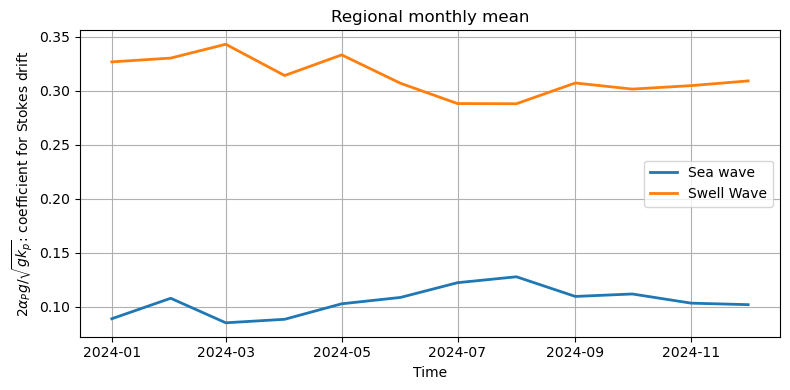

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    sea_monthly["time"].values,
    sea_monthly.values,
    label="Sea wave",
    linewidth=2
)

ax.plot(
    swell_monthly["time"].values,
    swell_monthly.values,
    label="Swell Wave",
    linewidth=2
)

ax.set_xlabel("Time")
ax.set_ylabel(r"$2\alpha_P g/\sqrt{g k_p}$: coefficient for Stokes drift")
ax.set_title("Regional monthly mean")
ax.legend()
ax.grid(True)

plt.tight_layout()
outpath = "/home/m/m301254/project_surfwaves/figs/icon-wave_testrun"
plt.savefig(f"{outpath}/stokes_drift_coef_compare_seawave_swell.png")
plt.show()


# ERA5: Estimate waves' influence on the structure, variability of Peruvian Coastal Upwelling system
- Three potential aspects:
    1. **Wave-mediated momentum -> change the stress that ocean "feels"**
        - Without wave: $\tau_{oc}=\tau_a$  ($\tau_{oc}=\tau_{oc}(\text{wind})$)
        - With wave: $\tau_{oc} = \tau_{a} - \tau_{in} -\tau_{ds}$  ($\tau_{oc}=\tau_{oc}(\text{wind, wave})$)
        - Directly Affect Ekman flow $v_{ek}$ (to the 1st-order)
    2. **Stokes transport -> modify the offshore mass transport (i.e., divergence of surface flow)**
        - Without wave (to the 1st-order): $w_{up}\sim \int_{-h}^{0} \nabla \cdot v_{ek}\;dz$, $w_{up}\sim \nabla \cdot V_{ek} $
        - With wave (to the 1st-order): $w_{up}\sim \int_{-h}^{0} \nabla \cdot (v_{ek}+v_{st})\;dz$, $w_{up}\sim \nabla \cdot (V_{ek}+V_{st})$
    3. **Wave-induced $\Delta \text{TKE}$ -> affect stratification -> affect ocean state -> ...?**
        - need to find the a "target" metric to analyse

In [16]:
era5_wind = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/era5_AtmosWinds_PeruCoast_2000-2024.grib", engine="cfgrib")
era5_wave = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/era5_SurfWaves_PeruCoast_2000-2024.grib",engine="cfgrib")

skipping variable: paramId==228003 shortName='zust'
Traceback (most recent call last):
  File "/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([ 946684800,  949363200,  951868800,  954547200,  957139200,
        959817600,  962409600,  965088000,  967766400,  970358400,
        973036800,  975628800,  978307200,  980985600,  983404800,
        986083200,  988675200,  991353600,  993945600,  996624000,
        999302400, 1001894400, 1004572800, 1007164800, 1009843200,
       1012521600, 1014940800, 1017619200, 1020211200, 1022889600,
       1025481600, 1028160000, 1030838400, 1033430400, 103610

In [4]:
era5_wave

<xarray.Dataset> Size: 71MB
Dimensions:            (time: 300, latitude: 61, longitude: 51)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2000-01-01 ... 2024-12-01
  * latitude           (latitude) float64 488B 5.0 4.5 4.0 ... -24.0 -24.5 -25.0
  * longitude          (longitude) float64 408B -95.0 -94.5 ... -70.5 -70.0
    number             int64 8B ...
    step               timedelta64[ns] 8B ...
    meanSea            float64 8B ...
    valid_time         (time) datetime64[ns] 2kB ...
    heightAboveGround  float64 8B ...
Data variables: (12/20)
    rhoao              (time, latitude, longitude) float32 4MB ...
    cdww               (time, latitude, longitude) float32 4MB ...
    mdts               (time, latitude, longitude) float32 4MB ...
    mdww               (time, latitude, longitude) float32 4MB ...
    mpts               (time, latitude, longitude) float32 4MB ...
    mpww               (time, latitude, longitude) float32 4MB ...
    ...                 ...
    swh                (time, latitude, longitude) float32 4MB ...
    shts               (time, latitude, longitude) float32 4MB ...
    shww               (time, latitude, longitude) float32 4MB ...
    ust                (time, latitude, longitude) float32 4MB ...
    vst                (time, latitude, longitude) float32 4MB ...
    surface            float64 8B ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-13T10:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
era5_wave.latitude

<xarray.DataArray 'latitude' (latitude: 61)> Size: 488B
array([  5. ,   4.5,   4. ,   3.5,   3. ,   2.5,   2. ,   1.5,   1. ,   0.5,
         0. ,  -0.5,  -1. ,  -1.5,  -2. ,  -2.5,  -3. ,  -3.5,  -4. ,  -4.5,
        -5. ,  -5.5,  -6. ,  -6.5,  -7. ,  -7.5,  -8. ,  -8.5,  -9. ,  -9.5,
       -10. , -10.5, -11. , -11.5, -12. , -12.5, -13. , -13.5, -14. , -14.5,
       -15. , -15.5, -16. , -16.5, -17. , -17.5, -18. , -18.5, -19. , -19.5,
       -20. , -20.5, -21. , -21.5, -22. , -22.5, -23. , -23.5, -24. , -24.5,
       -25. ])
Coordinates:
  * latitude           (latitude) float64 488B 5.0 4.5 4.0 ... -24.0 -24.5 -25.0
    number             int64 8B ...
    step               timedelta64[ns] 8B ...
    meanSea            float64 8B ...
    heightAboveGround  float64 8B ...
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

-  the wind-related output in the wave model:
    - `wind`: ocean surface stress equivalent 10 m neutral wind speed
    - `dwi`: ocean surface stress equivalent 10 m neutral wind direction, in degrees clockwise from true north\
        - **The neutral wind is, by definition, in the direction of the surface stress**. It is calculated from the surface stress and roughness length by assuming that the air is neutrally stratified. The size of the roughness length depends on the sea state.
    - `tauoc`: stress into the ocean normalised by atmospheric surface stress $\tau_a=\rho_{air}u_*^2$. The direction of ocean stress is the same as atmospheric surface stress, therefore identical to the direction of neutral 10m wind `dwi`
        - the `tauoc = 1 - X`, the higher the value, the closer to the surface stress, the less the effects of waves
        - atmospheric surface stress $\tau_a=\rho_{air}u_*^2 = \rho_{air}C_d||U_{10}||^2$, where $||U_{10}||$ is the magnitude of 10m neutral wind.
    - `phioc` and `phiaw`: energy flux into ocean/waves, normalised by $\rho_{air}u_*^3$
        - `phioc`: normalised vertical flux of turbulent kinetic energy from ocean waves into the ocean. The energy flux is calculated from an estimation of white capping waves across the surface of the ocean. When waves break in this way, there is a transfer of energy from the waves to the ocean. A negative flux implies a flux from the waves into the ocean.
        - `phiaw`: normalised vertical flux of energy from wind into the ocean waves. A positive flux implies a flux into the waves.

## Mean normalised ocean stress
- the ocean stress is normalised by atmospheric surface stress

In [17]:
# --- helper function for seasonal climatology ---
def seasonal_mean(ds, months):
    return ds.sel(time=ds.time.dt.month.isin(months)).mean("time")

# select region
era5_reg = era5_wave.sel(
    latitude=slice(0, -20),      # descending latitude
    longitude=slice(-90, -70)
)

In [5]:
# convert instantaneous stress to components
def stress_with_direction(tau, dwi):
    """Convert normalized stress magnitude + direction-from to u-,v-direction."""
    theta = np.deg2rad(dwi)
    tau_u = -tau * np.sin(theta)
    tau_v = -tau * np.cos(theta)
    return tau_u, tau_v

tauoc_u, tauoc_v = stress_with_direction(era5_reg["tauoc"], era5_reg["dwi"])

# mean
tauoc_ann = era5_reg["tauoc"].mean(dim="time")
tauoc_u_ann = tauoc_u.mean(dim="time")
tauoc_v_ann = tauoc_v.mean(dim="time")

tauoc_fma = seasonal_mean(era5_reg["tauoc"], [2, 3, 4])
tauoc_u_fma = seasonal_mean(tauoc_u, [2, 3, 4])
tauoc_v_fma = seasonal_mean(tauoc_v, [2, 3, 4])

tauoc_aso = seasonal_mean(era5_reg["tauoc"], [8, 9, 10])
tauoc_u_aso = seasonal_mean(tauoc_u, [8, 9, 10])
tauoc_v_aso = seasonal_mean(tauoc_v, [8, 9, 10])

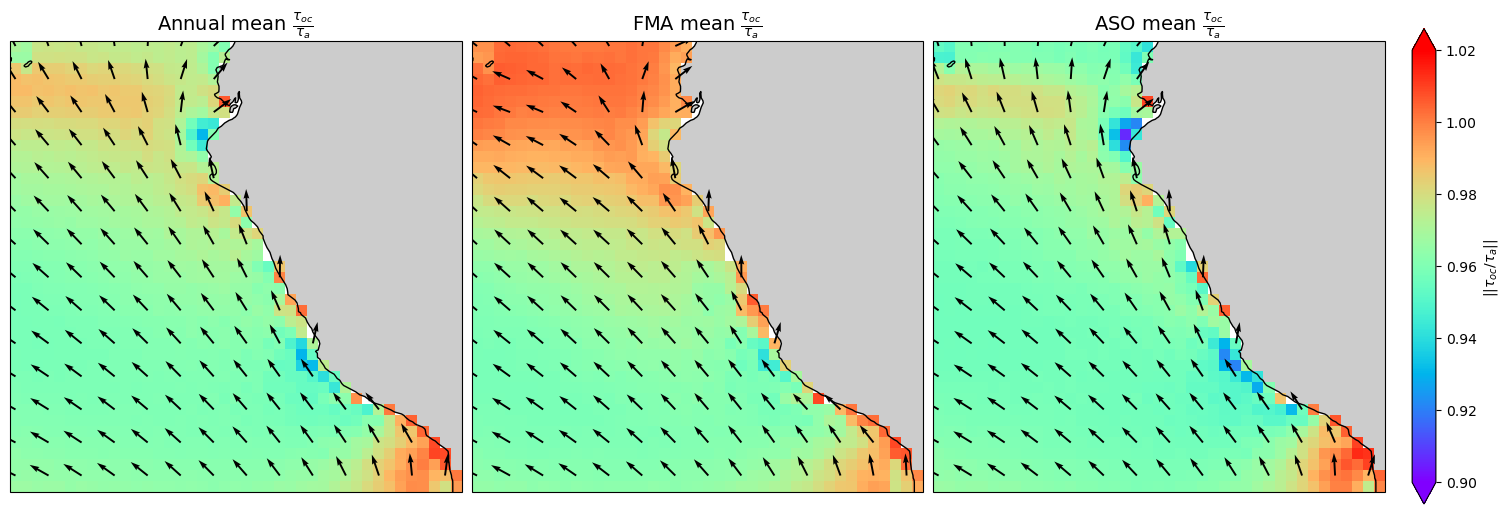

In [6]:
# Subsample for quiver clarity
skip = 3

fig, axs = plt.subplots(1, 3, figsize=(15, 5), 
                        subplot_kw={"projection": ccrs.PlateCarree()}, 
                        constrained_layout=True)

datasets = [
    (tauoc_ann, tauoc_u_ann, tauoc_v_ann, f"Annual mean $\\frac{{\\tau_{{oc}}}}{{\\tau_{{a}}}}$"),
    (tauoc_fma, tauoc_u_fma, tauoc_v_fma, f"FMA mean $\\frac{{\\tau_{{oc}}}}{{\\tau_{{a}}}}$"),
    (tauoc_aso, tauoc_u_aso, tauoc_v_aso, f"ASO mean $\\frac{{\\tau_{{oc}}}}{{\\tau_{{a}}}}$")
]

for ax, (mag, u, v, title) in zip(axs, datasets):
    # pcolormesh for magnitude
    pcm = ax.pcolormesh(
        mag.longitude, mag.latitude, mag,
        vmin=0.9, vmax=1.02,
        shading='auto', cmap='rainbow'
    )
    ax.set_xlabel("Lat")
    ax.set_ylabel("Lon")
    # quiver for direction
    ax.quiver(
        mag.longitude[::skip], mag.latitude[::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=20, color='k'
    )
    # ax.set_facecolor("0.8")
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
    ax.set_title(title, fontsize=14)
    

# Colorbar
cbar = fig.colorbar(pcm, ax=axs, orientation='vertical', extend="both", fraction=0.05, pad=0.02)
cbar.set_label(f"$||\\tau_{{oc}}/\\tau_{{a}}||$ ")

plt.show()

## Estimate Ekman transports
- Estimated as: $\mathbf{U}_{ek} \approx \tau_{oc} \times \hat{k} / \rho_w f = (\tau_{oc,y}/\rho_w f,-\tau_{oc,x}/\rho_w f )$

### Calculate atmospheric surface stress $\tau_{oc}=\tau_a$
- atmospheric surface stress: $\rho_{air}u_*^2=\rho_{air}(C_d||U_{10}||^2)$ 
    - variable name: `rhoao * cdww * wind**2`

In [7]:
# calculate the atmospheric surface stress term and assume it as the stress that ocean feels
taua = era5_reg["rhoao"] * era5_reg["cdww"] * era5_reg["wind"]**2 # only the magnitude
taua_u, taua_v = stress_with_direction(taua, era5_reg["dwi"])

In [8]:
# calculate the Ekman transport
def estimate_ekman_transport(tau_u, tau_v, rho_w=1025):
    """ Estimate the Stokes transport"""
    # Coriolis parameter f
    Omega = 7.2921e-5
    lat_rad = np.deg2rad(tau_u.latitude)
    f = 2 * Omega * np.sin(lat_rad)
    # transport in eastward (u) and northward (v) direction
    Uek_u =   tau_v / (rho_w * f)
    Uek_v = - tau_u / (rho_w * f)
    return Uek_u, Uek_v

Uek_u_taua, Uek_v_taua = estimate_ekman_transport(taua_u, taua_v) # unit: m^2 s-1

# drop out estimation when Lat within 5N to 5S (where f is too small to hold the estimation)
lat_mask = np.abs(Uek_u_taua.latitude) >= 5
Uek_u_taua = Uek_u_taua.where(lat_mask)
Uek_v_taua = Uek_v_taua.where(lat_mask)

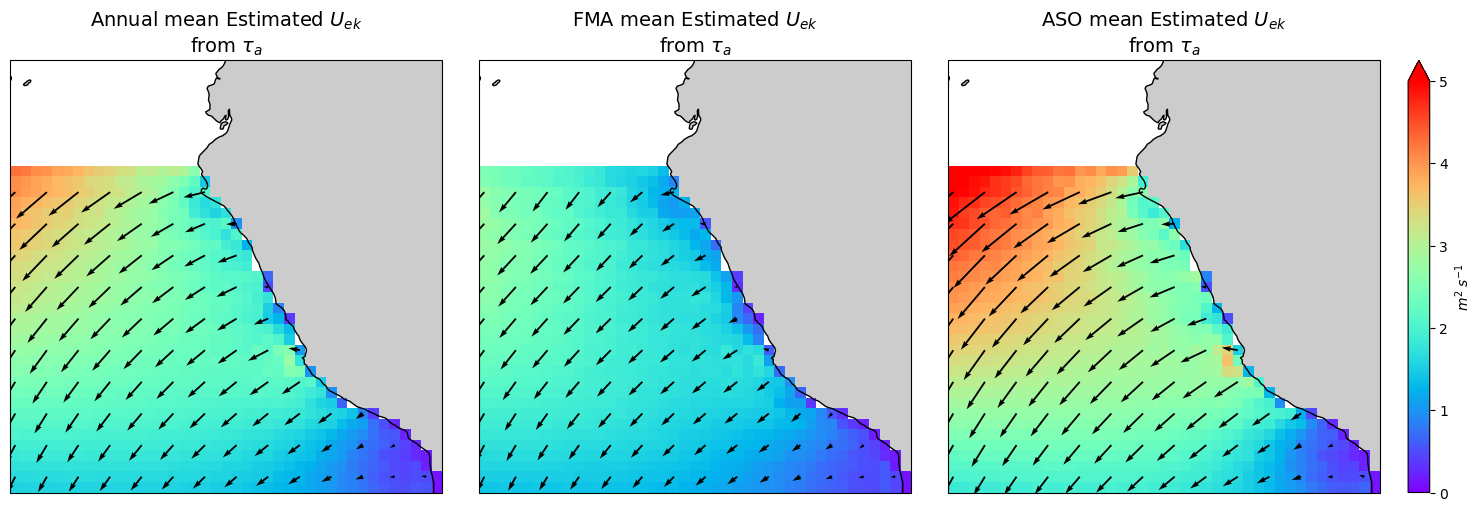

In [9]:
# mean
Uek_u_taua_ann = Uek_u_taua.mean(dim="time")
Uek_v_taua_ann = Uek_v_taua.mean(dim="time")
Uek_mag_ann = np.sqrt(Uek_u_taua_ann**2 + Uek_v_taua_ann**2)

Uek_u_taua_fma = seasonal_mean(Uek_u_taua, [2, 3, 4])
Uek_v_taua_fma = seasonal_mean(Uek_v_taua, [2, 3, 4])
Uek_mag_fma = np.sqrt(Uek_u_taua_fma**2 + Uek_v_taua_fma**2)

Uek_u_taua_aso = seasonal_mean(Uek_u_taua, [8, 9, 10])
Uek_v_taua_aso = seasonal_mean(Uek_v_taua, [8, 9, 10])
Uek_mag_aso = np.sqrt(Uek_u_taua_aso**2 + Uek_v_taua_aso**2)


# Subsample for quiver clarity
skip = 3
fig, axs = plt.subplots(1, 3, figsize=(15, 5), 
                        subplot_kw={"projection": ccrs.PlateCarree()}, 
                        constrained_layout=True)
datasets = [
    (Uek_mag_ann, Uek_u_taua_ann, Uek_v_taua_ann, f"Annual mean Estimated $U_{{ek}}$\nfrom $\\tau_{{a}}$"),
    (Uek_mag_fma, Uek_u_taua_fma, Uek_v_taua_fma, f"FMA mean Estimated $U_{{ek}}$\nfrom $\\tau_{{a}}$"),
    (Uek_mag_aso, Uek_u_taua_aso, Uek_v_taua_aso, f"ASO mean Estimated $U_{{ek}}$\nfrom $\\tau_{{a}}$")
]

for ax, (mag, u, v, title) in zip(axs, datasets):
    # pcolormesh for magnitude
    pcm = ax.pcolormesh(
        mag.longitude, mag.latitude, mag,
        vmin=0.0, vmax=5.0,
        shading='auto', cmap='rainbow'
    )
    # quiver for direction
    ax.quiver(
        mag.longitude[::skip], mag.latitude[::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=40, color='k'
    )
    ax.set_title(title, fontsize=14)
    # ax.set_facecolor("0.8")
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
    ax.set_xlabel("Lat")
    ax.set_ylabel("Lon")

# Colorbar
cbar = fig.colorbar(pcm, ax=axs, orientation='vertical', extend="max", fraction=0.05, pad=0.02)
cbar.set_label(f"$m^2\;s^{{-1}}$")

plt.show()


### Estimate from ocean stress (consider wave effects) $\tau_{oc}=\tau_a - \tau_{in} - \tau_{diss}$
- use the `tauoc` times the calculated atmospheric surface stress

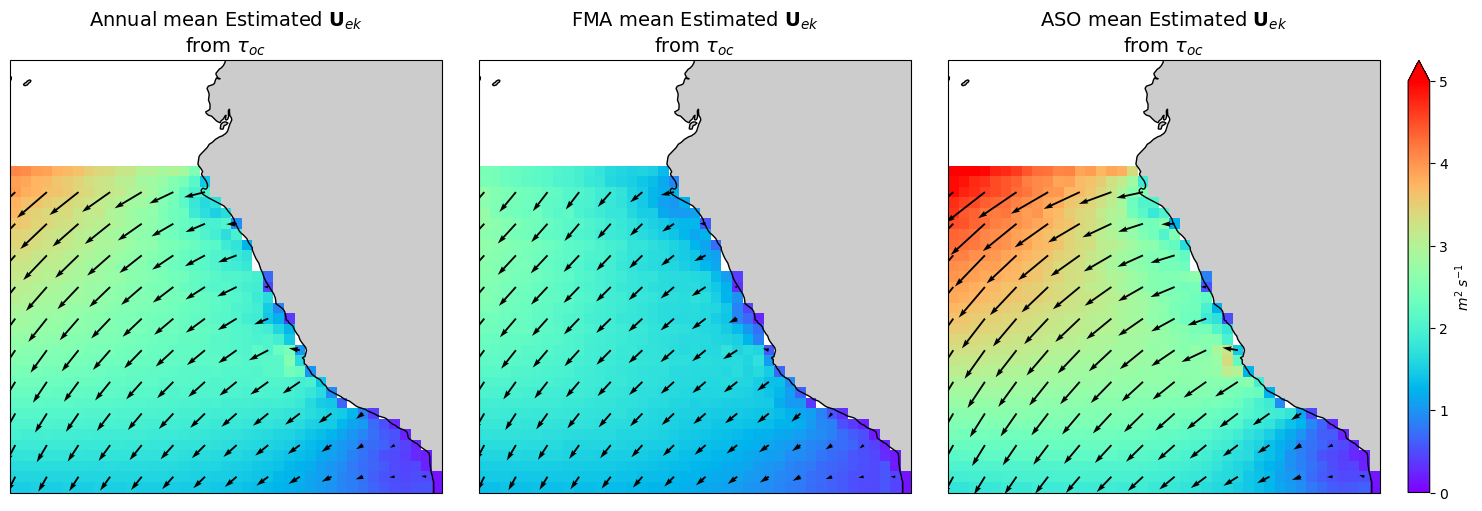

In [10]:
tauoc_denor = era5_reg["tauoc"] * taua
tauoc_denor_u, tauoc_denor_v = stress_with_direction(tauoc_denor, era5_reg["dwi"])

Uek_u_tauoc_denor, Uek_v_tauoc_denor = estimate_ekman_transport(tauoc_denor_u, tauoc_denor_v) # unit: m^2 s-1
lat_mask = np.abs(Uek_u_tauoc_denor.latitude) >= 5
Uek_u_tauoc_denor = Uek_u_tauoc_denor.where(lat_mask)
Uek_v_tauoc_denor = Uek_v_tauoc_denor.where(lat_mask)

# mean
Uek_u_tauoc_denor_ann = Uek_u_tauoc_denor.mean(dim="time")
Uek_v_tauoc_denor_ann = Uek_v_tauoc_denor.mean(dim="time")
Uek_mag_ann = np.sqrt(Uek_u_tauoc_denor_ann**2 + Uek_v_tauoc_denor_ann**2)

Uek_u_tauoc_denor_fma = seasonal_mean(Uek_u_tauoc_denor, [2, 3, 4])
Uek_v_tauoc_denor_fma = seasonal_mean(Uek_v_tauoc_denor, [2, 3, 4])
Uek_mag_fma = np.sqrt(Uek_u_tauoc_denor_fma**2 + Uek_v_tauoc_denor_fma**2)

Uek_u_tauoc_denor_aso = seasonal_mean(Uek_u_tauoc_denor, [8, 9, 10])
Uek_v_tauoc_denor_aso = seasonal_mean(Uek_v_tauoc_denor, [8, 9, 10])
Uek_mag_aso = np.sqrt(Uek_u_tauoc_denor_aso**2 + Uek_v_tauoc_denor_aso**2)


# Subsample for quiver clarity
skip = 3
fig, axs = plt.subplots(1, 3, figsize=(15, 5), 
                        subplot_kw={"projection": ccrs.PlateCarree()}, 
                        constrained_layout=True)
datasets = [
    (Uek_mag_ann, Uek_u_tauoc_denor_ann, Uek_v_tauoc_denor_ann, f"Annual mean Estimated $\mathbf{{U}}_{{ek}}$\nfrom $\\tau_{{oc}}$"),
    (Uek_mag_fma, Uek_u_tauoc_denor_fma, Uek_v_tauoc_denor_fma, f"FMA mean Estimated $\mathbf{{U}}_{{ek}}$\nfrom $\\tau_{{oc}}$"),
    (Uek_mag_aso, Uek_u_tauoc_denor_aso, Uek_v_tauoc_denor_aso, f"ASO mean Estimated $\mathbf{{U}}_{{ek}}$\nfrom $\\tau_{{oc}}$")
]

for ax, (mag, u, v, title) in zip(axs, datasets):
    # pcolormesh for magnitude
    pcm = ax.pcolormesh(
        mag.longitude, mag.latitude, mag,
        vmin=0.0, vmax=5.0,
        shading='auto', cmap='rainbow'
    )
    # quiver for direction
    ax.quiver(
        mag.longitude[::skip], mag.latitude[::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=40, color='k'
    )
    ax.set_title(title, fontsize=14)
    # ax.set_facecolor("0.8")
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
    ax.set_xlabel("Lat")
    ax.set_ylabel("Lon")

# Colorbar
cbar = fig.colorbar(pcm, ax=axs, orientation='vertical', extend="max", fraction=0.05, pad=0.02)
cbar.set_label(f"$m^2\;s^{{-1}}$")

plt.show()


## Mean surface Stokes drift (`ust, vst`) 

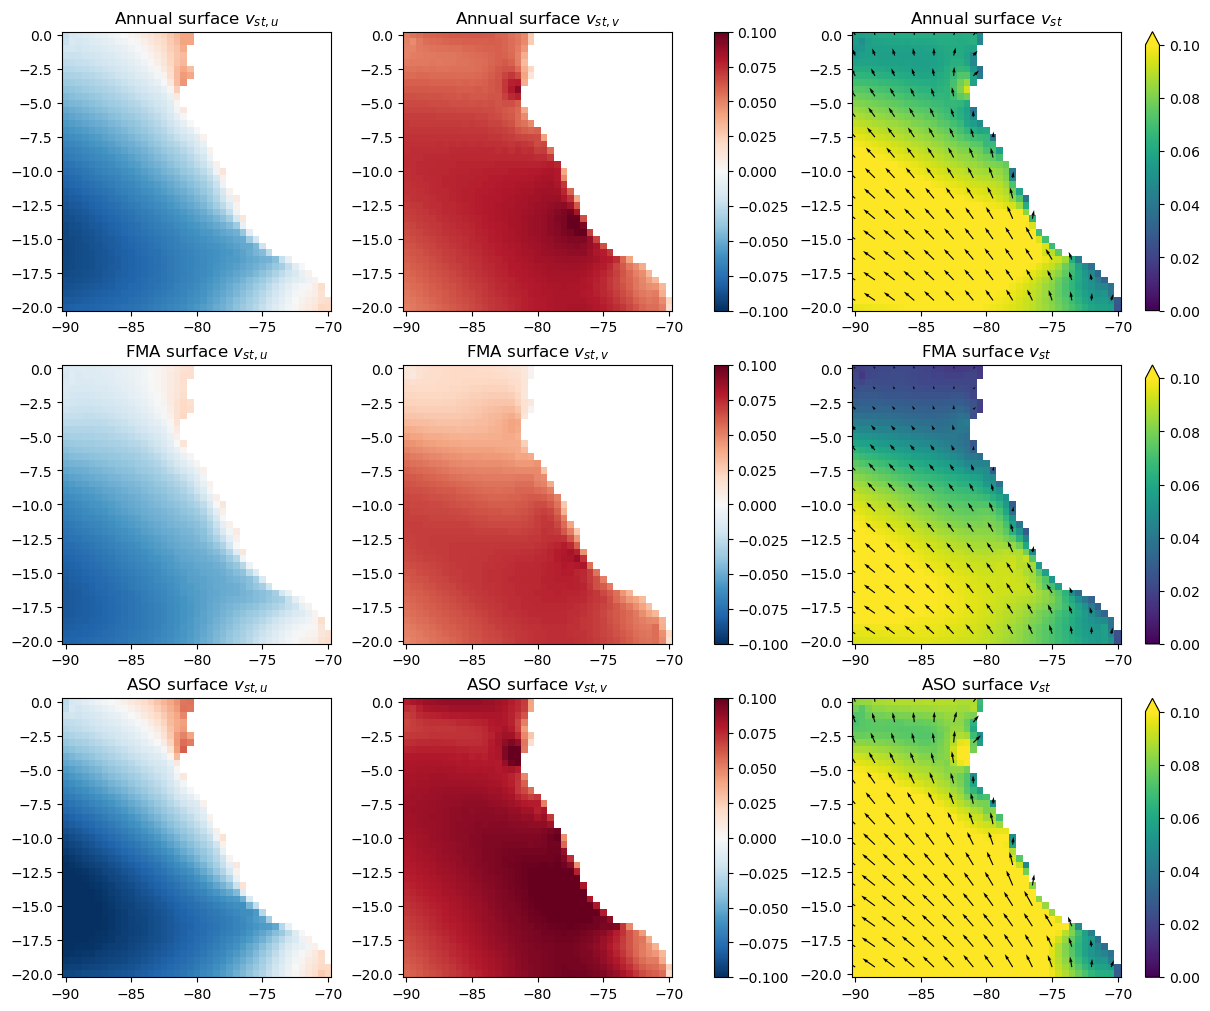

In [11]:
# Annual climatology
ust_ann = era5_reg["ust"].mean("time")
vst_ann = era5_reg["vst"].mean("time")

# Seasonal climatology
ust_fma = seasonal_mean(era5_reg["ust"], [2, 3, 4])
vst_fma = seasonal_mean(era5_reg["vst"], [2, 3, 4])

ust_aso = seasonal_mean(era5_reg["ust"], [8, 9, 10])
vst_aso = seasonal_mean(era5_reg["vst"], [8, 9, 10])

# --- plotting helper ---
def plot_row(ax_row, ust, vst, label):
    stokes_mag = np.sqrt(ust**2 + vst**2)
    # vmax = np.nanmax([abs(ust).max(), abs(vst).max()])
    vmax = 0.1
    vmin = -vmax
    # U component
    im = ust.plot(ax=ax_row[0], 
                  x="longitude", y="latitude",
                  cmap="RdBu_r", 
                  vmin=vmin, vmax=vmax,
                  add_colorbar=False
    )
    ax_row[0].set_title(f"{label} surface $v_{{st,u}}$")
    ax_row[0].set_xlabel("")
    ax_row[0].set_ylabel("")

    # V component
    vst.plot(ax=ax_row[1],
             x="longitude", y="latitude",
             cmap="RdBu_r",
             vmin=vmin, vmax=vmax,
             add_colorbar=False
    )
    ax_row[1].set_title(f"{label} surface $v_{{st,v}}$")
    ax_row[1].set_xlabel("")
    ax_row[1].set_ylabel("")

    # shared colorbar for U/V
    plt.gcf().colorbar(im, ax=ax_row[:2])

    # magnitude + arrows
    stokes_mag.plot(ax=ax_row[2], 
                    x="longitude", y="latitude",
                    cmap="viridis",
                    add_colorbar=True,
                    vmax=0.1, vmin=0.0,
    )

    skip = 3
    ax_row[2].quiver(era5_reg.longitude.values[::skip], era5_reg.latitude.values[::skip],
                     ust.values[::skip, ::skip], vst.values[::skip, ::skip], scale=2)
    ax_row[2].set_title(f"{label} surface $v_{{st}}$")
    ax_row[2].set_xlabel("")
    ax_row[2].set_ylabel("")


# --- create figure ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)

plot_row(axes[0], ust_ann, vst_ann, "Annual")
plot_row(axes[1], ust_fma, vst_fma, "FMA")
plot_row(axes[2], ust_aso, vst_aso, "ASO")

plt.show()


### Addition: 2024 monthly Surface stokes drift

In [12]:
ust_24 = era5_reg["ust"].sel(time=slice("2024-01-01", "2024-12-01"))
vst_24 = era5_reg["vst"].sel(time=slice("2024-01-01", "2024-12-01"))

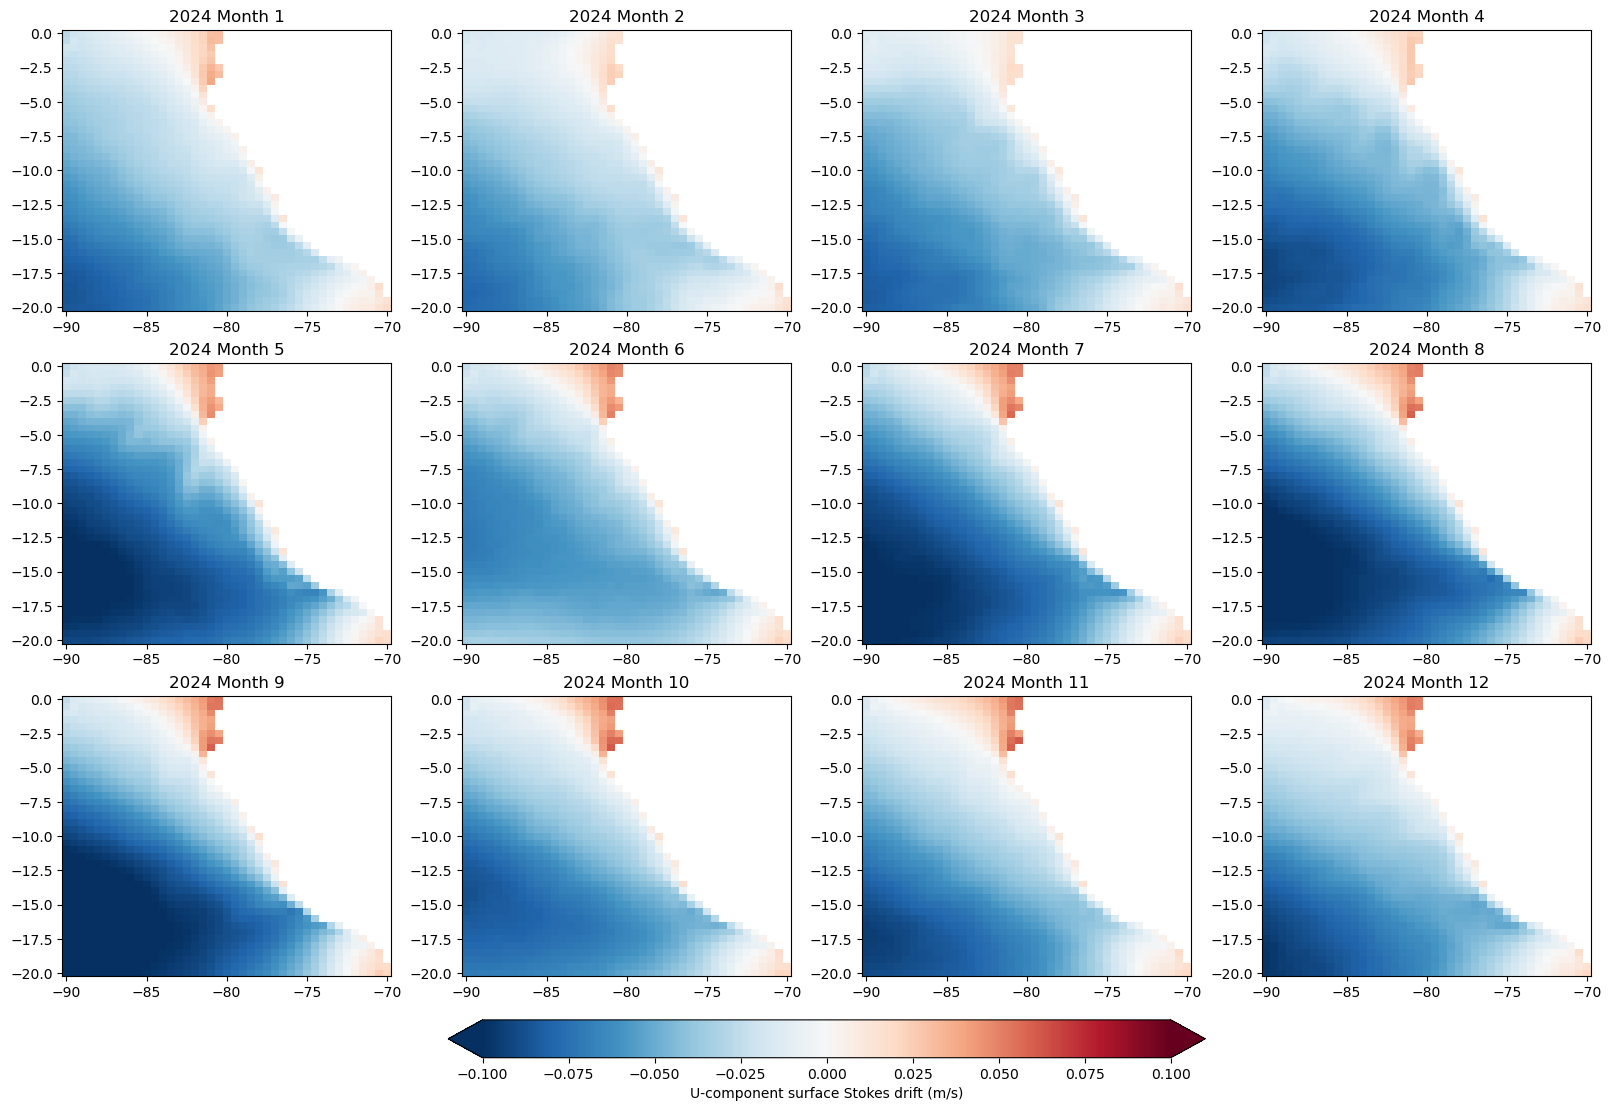

In [13]:
fig, axs = plt.subplots(3, 4, figsize=(16, 11), constrained_layout=True)

for i, ax in enumerate(axs.flat, start=0):
    da = ust_24.isel(time=i)

    pcm = ax.pcolormesh(
        da.longitude, da.latitude, da,
        vmin=-0.1, vmax=0.1,
        shading="auto",
        cmap="RdBu_r"
    )

    ax.set_title(f"2024 Month {i+1}")
    # ax.set_xlabel("Lon")
    # ax.set_ylabel("Lat")

# shared colorbar
fig.colorbar(pcm, ax=axs, orientation="horizontal",
             fraction=0.04, pad=0.02, extend="both",
             label="U-component surface Stokes drift (m/s)")


## Rough estimation of Stokes transport for (1) wind wave (ww) and (2) total swell (ts)
- formula: $V_s = \frac{\pi H_s^2}{8\bar{T}}(\sin{\bar{\theta}},\cos{\bar{\theta}})$
- assume:
    1. Deep water
    2. Each wave system (wind wave, swell) treated as monochromatic, as narrow-band spectrum
    3. Stokes transport direction $\approx$ mean wave direction
    4. Using bulk significant height $H_s=4\sqrt{m_0}$, mean wave period $\bar{T}=1/\bar{f}$, and mean wave direction $\bar{\theta}$
- The ECWAM explicitly output these mean wave quantities for both (1) wind waves and (2) total swells respectively. Thus, one can apply the estimation to roughly compare the contributions from two kinds
- It is evident that this rough estimate will overestimate the magnitude of the stokes transport by $\sim 20\% $

In [18]:
# calculation
def estimate_stokes_transport(Hs, T, theta_from_deg):
    """
    theta_drom_deg: the raw ERA5 data are degrees that waves are coming FROM, 
    so zero means 'coming from the north' and 90 'coming from the east'.
    """
    # convert coming from to propagating toward
    theta = np.deg2rad((theta_from_deg + 180) % 360)

    Vs_mag = np.pi * Hs**2 / (8 * T)
    Vs_u = Vs_mag * np.sin(theta) # eastward
    Vs_v = Vs_mag * np.cos(theta) # northward

    return Vs_u, Vs_v

In [19]:
# wind wave and total swell
Vs_u_ww, Vs_v_ww = estimate_stokes_transport(era5_reg["shww"], era5_reg["mpww"], era5_reg["mdww"])
Vs_u_ts, Vs_v_ts = estimate_stokes_transport(era5_reg["shts"], era5_reg["mpts"], era5_reg["mdts"])
Vs_u_total, Vs_v_total = estimate_stokes_transport(era5_reg["swh"], era5_reg["mwp"], era5_reg["mwd"])

# total
Vs_u = Vs_u_ww + Vs_u_ts
Vs_v = Vs_v_ww + Vs_v_ts

In [20]:
# climatology
# wind wave
Vs_u_ww_ann = Vs_u_ww.mean(dim="time")
Vs_v_ww_ann = Vs_v_ww.mean(dim="time")
Vs_u_ww_aso = seasonal_mean(Vs_u_ww, [8, 9, 10])
Vs_v_ww_aso = seasonal_mean(Vs_v_ww, [8, 9, 10])
Vs_u_ww_fma = seasonal_mean(Vs_u_ww, [2, 3, 4])
Vs_v_ww_fma = seasonal_mean(Vs_v_ww, [2, 3, 4])

# total swell
Vs_u_ts_ann = Vs_u_ts.mean(dim="time")
Vs_v_ts_ann = Vs_v_ts.mean(dim="time")
Vs_u_ts_aso = seasonal_mean(Vs_u_ts, [8, 9, 10])
Vs_v_ts_aso = seasonal_mean(Vs_v_ts, [8, 9, 10])
Vs_u_ts_fma = seasonal_mean(Vs_u_ts, [2, 3, 4])
Vs_v_ts_fma = seasonal_mean(Vs_v_ts, [2, 3, 4])

# total (ww + ts)
Vs_u_ann = Vs_u.mean(dim="time")
Vs_v_ann = Vs_v.mean(dim="time")
Vs_u_aso = seasonal_mean(Vs_u, [8, 9, 10])
Vs_v_aso = seasonal_mean(Vs_v, [8, 9, 10])
Vs_u_fma = seasonal_mean(Vs_u, [2, 3, 4])
Vs_v_fma = seasonal_mean(Vs_v, [2, 3, 4])

Vs_u_total_ann = Vs_u_total.mean(dim="time")
Vs_v_total_ann = Vs_v_total.mean(dim="time")
Vs_u_total_aso = seasonal_mean(Vs_u_total, [8, 9, 10])
Vs_v_total_aso = seasonal_mean(Vs_v_total, [8, 9, 10])
Vs_u_total_fma = seasonal_mean(Vs_u_total, [2, 3, 4])
Vs_v_total_fma = seasonal_mean(Vs_v_total, [2, 3, 4])

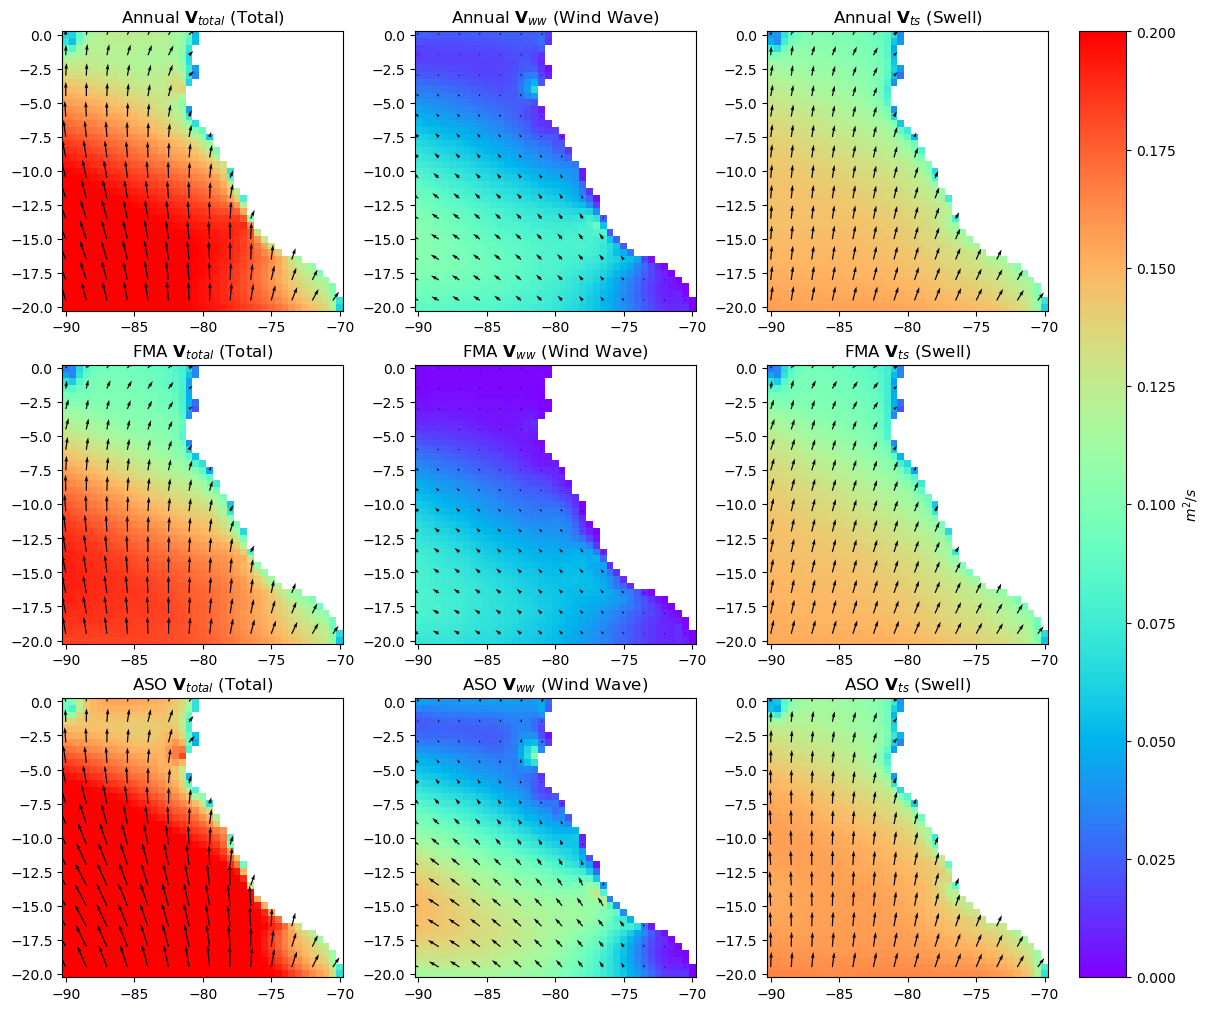

In [28]:
# --- helper function to plot a quiver panel ---
def plot_quiver(ax, u, v, title, skip=3):
    """
    ax   : matplotlib axis
    u,v  : x/y Stokes transport components (2D)
    title: subplot title
    skip : quiver subsampling
    """
    # magnitude for background color
    mag = np.sqrt(u**2 + v**2)
    
    # plot magnitude as background
    im = ax.pcolormesh(era5_reg["longitude"], era5_reg["latitude"],
                       mag, vmin=0.0, vmax=0.2, cmap="rainbow")
    # quiver arrows
    ax.quiver(era5_reg["longitude"].values[::skip], era5_reg["latitude"].values[::skip],
              u.values[::skip, ::skip], v.values[::skip, ::skip], 
              scale=3, color="k"
    )
    ax.set_title(title)
    
    return im  # for colorbar

# --- create 3x3 figure ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)

# --- Row 1: Annual ---
im0 = plot_quiver(axes[0,0], Vs_u_ann, Vs_v_ann, f"Annual $\\mathbf{{V}}_{{total}}$ (Total)")
plot_quiver(axes[0,1], Vs_u_ww_ann, Vs_v_ww_ann, f"Annual $\\mathbf{{V}}_{{ww}}$ (Wind Wave)")
plot_quiver(axes[0,2], Vs_u_ts_ann, Vs_v_ts_ann, f"Annual $\\mathbf{{V}}_{{ts}}$ (Swell)")

# --- Row 2: FMA ---
plot_quiver(axes[1,0], Vs_u_fma, Vs_v_fma, f"FMA $\\mathbf{{V}}_{{total}}$ (Total)")
plot_quiver(axes[1,1], Vs_u_ww_fma, Vs_v_ww_fma, f"FMA $\\mathbf{{V}}_{{ww}}$ (Wind Wave)")
plot_quiver(axes[1,2], Vs_u_ts_fma, Vs_v_ts_fma, f"FMA $\\mathbf{{V}}_{{ts}}$ (Swell)")

# --- Row 3: ASO ---
plot_quiver(axes[2,0], Vs_u_aso, Vs_v_aso, f"ASO $\\mathbf{{V}}_{{total}}$ (Total)")
plot_quiver(axes[2,1], Vs_u_ww_aso, Vs_v_ww_aso, f"ASO $\\mathbf{{V}}_{{ww}}$ (Wind Wave)")
plot_quiver(axes[2,2], Vs_u_ts_aso, Vs_v_ts_aso, f"ASO $\\mathbf{{V}}_{{ts}}$ (Swell)")

# --- shared colorbar ---
cbar = fig.colorbar(
    im0,
    ax=axes,
    orientation="vertical",
    label=f"$m^2/s$",
    pad = 0.02,
)

plt.show()


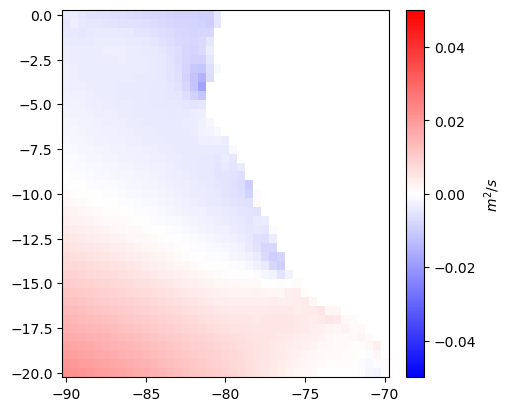

In [26]:
# estimation from mean wave - estimation from ww + ts
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

mag1 = np.sqrt(Vs_u_total_ann**2 + Vs_v_total_ann**2)
mag2 = np.sqrt(Vs_u_ann**2 + Vs_v_ann**2)

# plot magnitude as background
im = ax.pcolormesh(era5_reg["longitude"], era5_reg["latitude"],
                    mag1-mag2, vmin=-0.05, vmax=0.05, cmap="bwr")

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    label=f"$m^2/s$",
    pad = 0.02,
)

plt.show()

In [27]:
print(mag1-mag2)

<xarray.DataArray (latitude: 41, longitude: 41)> Size: 7kB
array([[-0.00421038, -0.00388892, -0.00491977, ...,         nan,
                nan,         nan],
       [-0.00500012, -0.00350235, -0.00457484, ...,         nan,
                nan,         nan],
       [-0.0044462 , -0.00440758, -0.00503159, ...,         nan,
                nan,         nan],
       ...,
       [ 0.0192738 ,  0.01885033,  0.01823203, ..., -0.00039968,
         0.00171346,         nan],
       [ 0.02056235,  0.01999938,  0.01948248, ..., -0.00125392,
        -0.00072426,  0.00091325],
       [ 0.02173796,  0.02121711,  0.02064268, ..., -0.00174466,
        -0.00225051,  0.00097365]], shape=(41, 41), dtype=float32)
Coordinates:
  * latitude           (latitude) float64 328B 0.0 -0.5 -1.0 ... -19.5 -20.0
  * longitude          (longitude) float64 328B -90.0 -89.5 ... -70.5 -70.0
    number             int64 8B 0
    step               timedelta64[ns] 8B 00:00:00
    meanSea            float64 8B 0.0
    heig

- **Estimates suggest that total swell waves dominate both the magnitude and direction of Stokes transport in the study region**.
    - **Wind waves generally propagate in the direction of the alongshore winds**. The associated Stokes drift exhibits an offshore component, which may contribute to offshore water-mass transport. In addition, wind waves show pronounced seasonality, broadly consistent with the seasonal variability of the local alongshore winds.
    - **Total swells predominantly propagate northeastward toward the coast**, potentially generating Stokes transport that partly opposes the offshore Ekman transport. Unlike wind waves, total swells show relatively small differences between the Aug–Sep–Oct and Feb–Mar–Apr mean states, although seasonal variability may still be evident during other periods.
- Although Stokes drift is strongest near the surface, where it's intensity and direction is primarily controlled by wind waves, the depth-integrated Stokes transport in the study region appears to be more strongly influenced by swells.
    - This potentially suggests strong veering occurs in the Stokes drift profiles in the study region, indicating the strong influence from the remote swells.

## Horizontal divergence of (1) Ekman transport; (2) Stokes transport
- Continuity equation: $\nabla \cdot (v_{ek}+v{st}) + \partial w/\partial z = 0$
    - After integration: $w \sim - \nabla \cdot (\mathbf{V}_{ek}+\mathbf{V}_{st})$, where the capital indicates the transport (vertical integrated)
        - Here, we neglect the difference in integral depth, as the estimated Ekman transport $\mathbf{U}_{ek}$ is assumed to integrate over the wind affect layer; And the Stokes transport $\mathbf{U}_{st}$ is also estimated across the whole Stokes drift profile (which should be relativly shallow)

In [18]:
# Ekman transport: Uek_u_tauoc_denor, Uek_v_tauoc_denor
Uek_u = Uek_u_tauoc_denor
Uek_v = Uek_v_tauoc_denor
# Stokes drift: Vs_u, Vs_v
Vs_u = Vs_u.where(lat_mask)
Vs_v = Vs_v.where(lat_mask)

In [20]:
# function to calculate the minus divergence
def minus_divergence_spherical(M_u, M_v, R=6371000):
    """
    Compute -divergence of horizontal transport on a spherical lat-lon grid.
    Parameters
    ----------
    M_u : xarray.DataArray
        Zonal transport (eastward), dims include 'latitude','longitude'.
    M_v : xarray.DataArray
        Meridional transport (northward).
    R : float
        Earth radius in meters (default 6371000 m).
    Returns
    -------
    w : xarray.DataArray
        Minus divergence (-∇·M), same dims as input.
        Often interpreted as Ekman pumping velocity.
    """
    # latitude in radians
    lat_rad = np.deg2rad(M_u.latitude)

    # convert derivative per degree → per radian
    dMdlon = M_u.differentiate("longitude") * np.pi / 180
    dMdlat = (M_v * np.cos(lat_rad)).differentiate("latitude") * np.pi / 180

    # spherical divergence
    divM = (
        dMdlon / (R * np.cos(lat_rad))
        + dMdlat / (R * np.cos(lat_rad))
    )

    return -divM

In [21]:
# Ekman pumping velocity
wE = minus_divergence_spherical(Uek_u, Uek_v)
wS = minus_divergence_spherical(Vs_u, Vs_v)
wTotal = minus_divergence_spherical(Uek_u+Vs_u, Uek_v+Vs_v)

In [34]:
wE

<xarray.DataArray (time: 300, latitude: 41, longitude: 41)> Size: 4MB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [ 3.70300026e-10,  3.03054748e-10,  3.29767272e-10, ...,
         -7.27655255e-10,             nan,             nan],
        [ 4.73782015e-10,  5.00017420e-10,  3.85226876e-10, ...,
         -8.40027288e-11, -8.41523421e-10,             nan],
        [ 6.09110511e-10,  6.87440432e-10,  4.69849891e-10, ...,
          1.69829474e-10, -7.11048542e-10, -1.67960716e-09]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
...
         -1.45555326e-10,             nan,             nan],
        [ 5.99660089e-10,  6.11420948e-10,  4.67540993e-10, ...,
          3.94428408e-10, -5.76990409e-10,             nan],
        [ 7.50430474e-10,  7.97872317e-10,  5.59354594e-10, ...,
          5.51185703e-10, -4.38955060e-10, -1.87870449e-09]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [ 3.58504732e-10,  2.72463301e-10,  1.67299494e-10, ...,
         -3.78623413e-10,             nan,             nan],
        [ 3.39772146e-10,  3.12108698e-10,  2.51936999e-10, ...,
          9.74228747e-11, -6.73729493e-10,             nan],
        [ 4.73888100e-10,  3.34717192e-10,  2.67647628e-10, ...,
          4.98372402e-10, -4.22575545e-10, -1.85545882e-09]]],
      shape=(300, 41, 41))
Coordinates:
  * time               (time) datetime64[ns] 2kB 2000-01-01 ... 2024-12-01
  * latitude           (latitude) float64 328B 0.0 -0.5 -1.0 ... -19.5 -20.0
  * longitude          (longitude) float64 328B -90.0 -89.5 ... -70.5 -70.0
    number             int64 8B 0
    step               timedelta64[ns] 8B 00:00:00
    meanSea            float64 8B 0.0
    valid_time         (time) datetime64[ns] 2kB 2000-01-01 ... 2024-12-01
    heightAboveGround  float64 8B 10.0

(array([4.90000e+01, 5.32000e+02, 2.71080e+04, 1.88393e+05, 2.96840e+04,
        2.60300e+03, 8.26000e+02, 3.06000e+02, 8.80000e+01, 1.10000e+01]),
 array([-1.84756701e-10, -1.34697195e-10, -8.46376899e-11, -3.45781844e-11,
         1.54813211e-11,  6.55408266e-11,  1.15600332e-10,  1.65659838e-10,
         2.15719343e-10,  2.65778849e-10,  3.15838354e-10]),
 <BarContainer object of 10 artists>)

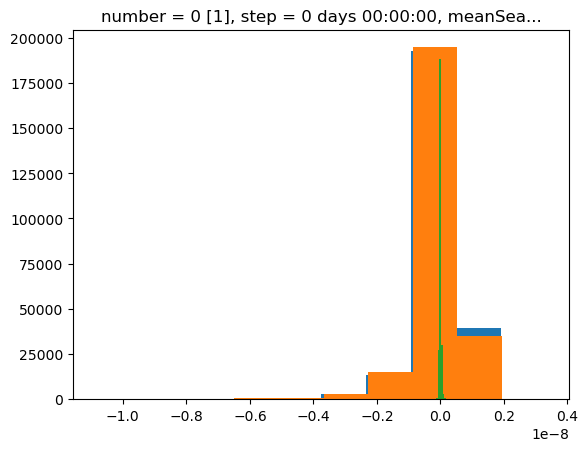

In [23]:
wTotal.plot()
wE.plot()
wS.plot()

In [ ]:
# time mean
wTotal_clim = wTotal.mean(dim="time")
wE_clim = wE.mean(dim="time")
wS_clim = wS.mean(dim="time")


<xarray.DataArray (latitude: 41, longitude: 41)> Size: 13kB
array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       ...,
       [ 4.70187092e-10,  5.38763045e-10,  5.20002544e-10, ...,
        -4.35461266e-10,             nan,             nan],
       [ 5.19495124e-10,  5.44693959e-10,  4.56270063e-10, ...,
         2.88425258e-10, -7.36111928e-10,             nan],
       [ 6.25223123e-10,  6.39156547e-10,  4.72311038e-10, ...,
         2.70289637e-10, -7.29937812e-10, -2.25880558e-09]],
      shape=(41, 41))
Coordinates:
  * latitude           (latitude) float64 328B 0.0 -0.5 -1.0 ... -19.5 -20.0
  * longitude          (longitude) float64 328B -90.0 -89.5 ... -70.5 -70.0
    number             int64 8B 0
    step               timedelta64[ns] 8B 00:00:00
    meanSea            float64 8B 0.0
    heightAboveGround  float64 8B 10.0

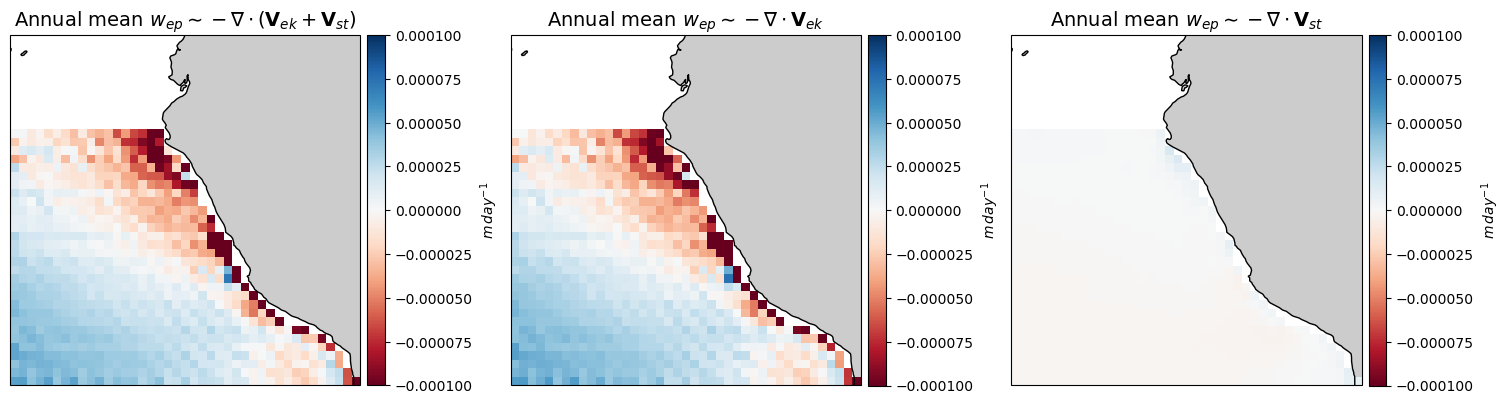

In [33]:
fig, axs = plt.subplots(
    1, 3, figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

datasets = [
    (wTotal_clim * 60 * 60 * 24, r"Annual mean $w_{ep} \sim -\nabla \cdot (\mathbf{V}_{ek}+\mathbf{V}_{st})$"),
    (wE_clim * 60 * 60 * 24,     r"Annual mean $w_{ep} \sim -\nabla \cdot \mathbf{V}_{ek}$"),
    (wS_clim * 60 * 60 * 24,     r"Annual mean $w_{ep} \sim -\nabla \cdot \mathbf{V}_{st}$")
]

for ax, (mag, title) in zip(axs, datasets):

    pcm = ax.pcolormesh(
        mag.longitude, mag.latitude, mag,
        vmin=-1e-4, vmax=1e-4,
        shading='auto', cmap='RdBu'
    )

    ax.set_title(title, fontsize=14)
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # ⭐ individual colorbar
    cbar = fig.colorbar(
        pcm, ax=ax,
        orientation="vertical",
        fraction=0.05, pad=0.02
    )
    cbar.set_label(r"$m\,day^{-1}$")

plt.show()


- mathmatically, the **divergence of the Ekman transport $\mathbf{V}_{ek}$** is also associated to **curl of the ocean stress $\tau_{oc}$**
    - $\nabla \cdot \mathbf{V}_{ek} = \nabla \cdot (\frac{\tau_{oc,y}}{\rho_w f}, -\frac{\tau_{oc,x}}{\rho_w f}) = \frac{1}{\rho_w f}(\nabla \times \tau_{oc})_z$
    - The curl measures how stress rotates spatially, involving changing in both magnitude and direction, for example
        - Gradient prependicular to wind direction
        - Wind direction changes spatially

# ERA5: Estimates the Stokes transport of heat across Equatorial Pacific
- **Context**: 
    - the mean Stokes transport, which is largely modulated by the swells, can travel and propagate across the equator, which might induce a significant amount of time mean heat transport that the upper ocean mean currents cannot
    - It might incorporate large seasonality. As the storms-rich season in two hemispheres are different. The swell generation (mainly from storms) might also show great seasonality, and so does the seasonal mean Stokes transport of heat.

- **Be careful**:
    - the actual amount might be very small!
    - One need to consider the **Stokes transport is net Lagrangian transport**. It doesn't correspond to a steady Eulerian current. 
        - The ocean obeys the incompressibility, if waves produce a net drift, mass would accumulate otherwise.
        - Thus the **ocean develops a weak compensating Eulerian flow, often called anti-Stokes flow**.
        - It ensures that the mass transport will be cancelled.
    - Even if mass transport cancels, the tracer (e.g., Heat/salt/plankton) may still move --> effective tracer transport
        - e.g., warm surafce water moves north via Stokes drift, slightly cooler subsurface return flow south --> net northward heat transport

- **Estimation**: $Q \approx \rho_w c_p \int \bar{V_st}(x,t)\bar{SST}(x,t)\; dx$
    - Key assumptions:
        1. SST represents temperature of transported water. Reasonable since Stokes transport is typically confined to the upper 10 meters and mixed layer temperature is often vertically uniform
        2. Estimated Stokes transport ($V_s = \frac{\pi H_s^2}{8\bar{T}}(\sin{\bar{\theta}},\cos{\bar{\theta}})$) is the net Lagrangian water transport. It's a diagnostic of wave-induced traver redistribution

In [2]:
wave_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/era5_SurfWaves_global_2000-2024.grib",engine="cfgrib")
sst_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/era5_SST_global_1950-2024.grib",engine="cfgrib")

skipping variable: paramId==34 shortName='sst'
Traceback (most recent call last):
  File "/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='latitude' value=Variable(dimensions=('latitude',), data=array([ 90. ,  89.5,  89. ,  88.5,  88. ,  87.5,  87. ,  86.5,  86. ,
        85.5,  85. ,  84.5,  84. ,  83.5,  83. ,  82.5,  82. ,  81.5,
        81. ,  80.5,  80. ,  79.5,  79. ,  78.5,  78. ,  77.5,  77. ,
        76.5,  76. ,  75.5,  75. ,  74.5,  74. ,  73.5,  73. ,  72.5,
        72. ,  71.5,  71. ,  70.5,  70. ,  69.5,  69. ,  68.5,  68. ,
        67.5,  67. ,  66.5,  66. ,  65.5,  65. ,  64.5,  64. ,  63.5,
        63. ,  62.5,  62. ,  61.5,  61. 

In [3]:
wave_globe

<xarray.Dataset> Size: 4GB
Dimensions:            (time: 300, latitude: 361, longitude: 720)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2000-01-01 ... 2024-12-01
  * latitude           (latitude) float64 3kB 90.0 89.5 89.0 ... -89.5 -90.0
  * longitude          (longitude) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
    number             int64 8B ...
    step               timedelta64[ns] 8B ...
    meanSea            float64 8B ...
    valid_time         (time) datetime64[ns] 2kB ...
    heightAboveGround  float64 8B ...
Data variables: (12/15)
    mwd                (time, latitude, longitude) float32 312MB ...
    mwp                (time, latitude, longitude) float32 312MB ...
    surface            float64 8B ...
    swh                (time, latitude, longitude) float32 312MB ...
    rhoao              (time, latitude, longitude) float32 312MB ...
    cdww               (time, latitude, longitude) float32 312MB ...
    ...                 ...
    mpww               (time, latitude, longitude) float32 312MB ...
    tauoc              (time, latitude, longitude) float32 312MB ...
    dwi                (time, latitude, longitude) float32 312MB ...
    wind               (time, latitude, longitude) float32 312MB ...
    shts               (time, latitude, longitude) float32 312MB ...
    shww               (time, latitude, longitude) float32 312MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-23T13:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
# interpolate SST onto wave grid
sst_on_wave = sst_globe['sst'].interp(
    latitude=wave_globe.latitude,
    longitude=wave_globe.longitude,
    method="linear"
)

## Cross-equatorial heat transport by wave

In [4]:
# select time
sst_time = sst_on_wave.sel(time=slice("2000-01-01", "2024-12-01"))

# select region: Indo-Pacific
wave_eq_IP = wave_globe.sel(latitude=slice(2, -2), longitude=slice(35, 285))
sst_eq_IP  = sst_time.sel(latitude=slice(2, -2), longitude=slice(35, 285))

# select region: Pacific
wave_eq_P = wave_globe.sel(latitude=slice(2, -2), longitude=slice(120, 285))
sst_eq_P  = sst_time.sel(latitude=slice(2, -2), longitude=slice(120, 285))

In [5]:
# Estimate the Stokes transport
def estimate_stokes_transport(Hs, T, theta_from_deg):
    """
    theta_drom_deg: the raw ERA5 data are degrees that waves are coming FROM, 
    so zero means 'coming from the north' and 90 'coming from the east'.
    """
    # convert coming from to propagating toward
    theta = np.deg2rad((theta_from_deg + 180) % 360)

    Vs_mag = np.pi * Hs**2 / (8 * T)
    Vs_u = Vs_mag * np.sin(theta) # eastward
    Vs_v = Vs_mag * np.cos(theta) # northward

    return Vs_u, Vs_v

# Indo-Pacific
# wind wave and total swell
Vst_u_ww_IP, Vst_v_ww_IP = estimate_stokes_transport(wave_eq_IP["shww"], wave_eq_IP["mpww"], wave_eq_IP["mdww"])
Vst_u_ts_IP, Vst_v_ts_IP = estimate_stokes_transport(wave_eq_IP["shts"], wave_eq_IP["mpts"], wave_eq_IP["mdts"])
# total
Vst_u_IP = Vst_u_ww_IP + Vst_u_ts_IP
Vst_v_IP = Vst_v_ww_IP + Vst_v_ts_IP

# Pacific
# wind wave and total swell
Vst_u_ww_P, Vst_v_ww_P = estimate_stokes_transport(wave_eq_P["shww"], wave_eq_P["mpww"], wave_eq_P["mdww"])
Vst_u_ts_P, Vst_v_ts_P = estimate_stokes_transport(wave_eq_P["shts"], wave_eq_P["mpts"], wave_eq_P["mdts"])
# total
Vst_u_P = Vst_u_ww_P + Vst_u_ts_P
Vst_v_P = Vst_v_ww_P + Vst_v_ts_P

In [6]:
# Focus only on the meridional transport (V-component)
rho_w = 1025 # kg m-3
cp = 3985    # J kg-1 K-1

# Indo-Pacific
HT_IP = rho_w * cp * Vst_v_IP * (sst_eq_IP - 273.15)       # unit: (kg m-3) * (J kg-1 K-1) * (m2 s-1) * (K) = J m-1 s-1
HT_ww_IP = rho_w * cp * Vst_v_ww_IP * (sst_eq_IP - 273.15)
HT_ts_IP = rho_w * cp * Vst_v_ts_IP * (sst_eq_IP - 273.15)

# Pacific
HT_P = rho_w * cp * Vst_v_P * (sst_eq_P - 273.15)          # unit: kg m-3 * J kg-1 K-1 * m2 s-1 * K = J m-1 s-1
HT_ww_P = rho_w * cp * Vst_v_ww_P * (sst_eq_P - 273.15)
HT_ts_P = rho_w * cp * Vst_v_ts_P * (sst_eq_P - 273.15)

In [14]:
# equatorial mean 
# Indo-Pacific
eq_mean_IP = HT_IP.mean(dim="latitude")
eq_mean_ww_IP = HT_ww_IP.mean(dim="latitude")
eq_mean_ts_IP = HT_ts_IP.mean(dim="latitude")

# Indo-Pacific
eq_mean_P = HT_P.mean(dim="latitude")
eq_mean_ww_P = HT_ww_P.mean(dim="latitude")
eq_mean_ts_P = HT_ts_P.mean(dim="latitude")

Text(0.5, 1.0, 'Pacific')

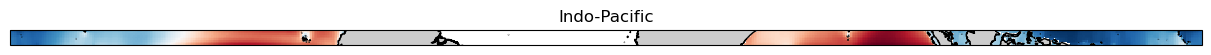

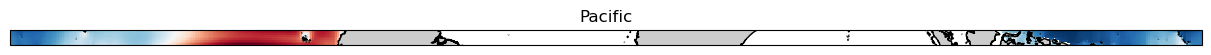

In [46]:
mean_ht = HT_IP.mean(dim="time")
fig, ax = plt.subplots(1,1, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)
pcm = ax.pcolormesh(
        mean_ht.longitude, mean_ht.latitude, mean_ht,
        # vmin=-1e-4, vmax=1e-4,
        shading='auto', cmap='RdBu_r'
)

# ax.set_title(title, fontsize=14)
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Indo-Pacific")


# heat_transport
mean_ht = HT_P.mean(dim="time")
fig, ax = plt.subplots(1,1, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)
pcm = ax.pcolormesh(
        mean_ht.longitude, mean_ht.latitude, mean_ht,
        # vmin=-1e-4, vmax=1e-4,
        shading='auto', cmap='RdBu_r'
)

# ax.set_title(title, fontsize=14)
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Pacific")

In [ ]:
# calculate dx
R = 6371000
lat0 = np.deg2rad(HT_IP.latitude.mean().values)
dlon = np.deg2rad(eq_mean_IP.longitude.diff("longitude").mean().values)
dx = R * np.cos(lat0) * dlon                      # unit: m

# integrate over equator (longitude)
Q_total = (eq_mean_IP * dx).sum("longitude")      # unit: kg m-3 * J kg-1 K-1 * m2 s-1 * K * m = J s-1 = W
Q_ww = (eq_mean_ww_IP * dx).sum("longitude")
Q_ts = (eq_mean_ts_IP * dx).sum("longitude")

# convert to PW (e15 W)
Q_total /= 1e15
Q_ww /= 1e15
Q_ts /= 1e15

# averaging over month
Q_total_months = Q_total.groupby("time.month").mean()
Q_ww_months = Q_ww.groupby("time.month").mean()
Q_ts_months = Q_ts.groupby("time.month").mean()

# averaging over years
Q_total_years = Q_total.groupby("time.year").mean()
Q_ww_years = Q_ww.groupby("time.year").mean()
Q_ts_years = Q_ts.groupby("time.year").mean()


In [58]:
def heat_transport_equatorial_integration(full_heat_transport, 
                                          equator_mean_heat_transport, 
                                          equator_mean_heat_transport_ww, 
                                          equator_mean_heat_transport_ts):
    """
    calculate the sum over the equator (i.e., zonal integration) of
    the heat transport, done by the total heat transport, and relative contributions
    from wind-wave (ww) and total swell (ts)
    """
    # calculate dx
    R = 6371000
    lat0 = np.deg2rad(full_heat_transport.latitude.mean().values)
    dlon = np.deg2rad(equator_mean_heat_transport.longitude.diff("longitude").mean().values)
    dx = R * np.cos(lat0) * dlon                      # unit: m

    # integrate over equator (longitude)
    Q_total = (equator_mean_heat_transport * dx).sum("longitude")      # unit: kg m-3 * J kg-1 K-1 * m2 s-1 * K * m = J s-1 = W
    Q_ww = (equator_mean_heat_transport_ww * dx).sum("longitude")
    Q_ts = (equator_mean_heat_transport_ts * dx).sum("longitude")

    # convert to PW (e15 W)
    Q_total /= 1e15
    Q_ww /= 1e15
    Q_ts /= 1e15

    # averaging over month
    Q_total_months = Q_total.groupby("time.month").mean()
    Q_ww_months = Q_ww.groupby("time.month").mean()
    Q_ts_months = Q_ts.groupby("time.month").mean()

    # averaging over years
    Q_total_years = Q_total.groupby("time.year").mean()
    Q_ww_years = Q_ww.groupby("time.year").mean()
    Q_ts_years = Q_ts.groupby("time.year").mean()

    # create dataset
    ds = xr.Dataset(
        {
            "Qtot": Q_total,
            "Qww": Q_ww,
            "Qts": Q_ts,
            "Qtot_months": Q_total_months,
            "Qww_months": Q_ww_months,
            "Qts_months": Q_ts_months,
            "Qtot_years": Q_total_years,
            "Qww_years": Q_ww_years,
            "Qts_years": Q_ts_years,
        }
    )

    ds.attrs["units"] = "PW"
    ds.attrs["description"] = "Cross-equatorial Stokes heat transport"

    return ds

In [59]:
ds_IP = heat_transport_equatorial_integration(HT_IP,
                                              eq_mean_IP,
                                              eq_mean_ww_IP,
                                              eq_mean_ts_IP)

ds_P = heat_transport_equatorial_integration(HT_P,
                                              eq_mean_P,
                                              eq_mean_ww_P,
                                              eq_mean_ts_P)

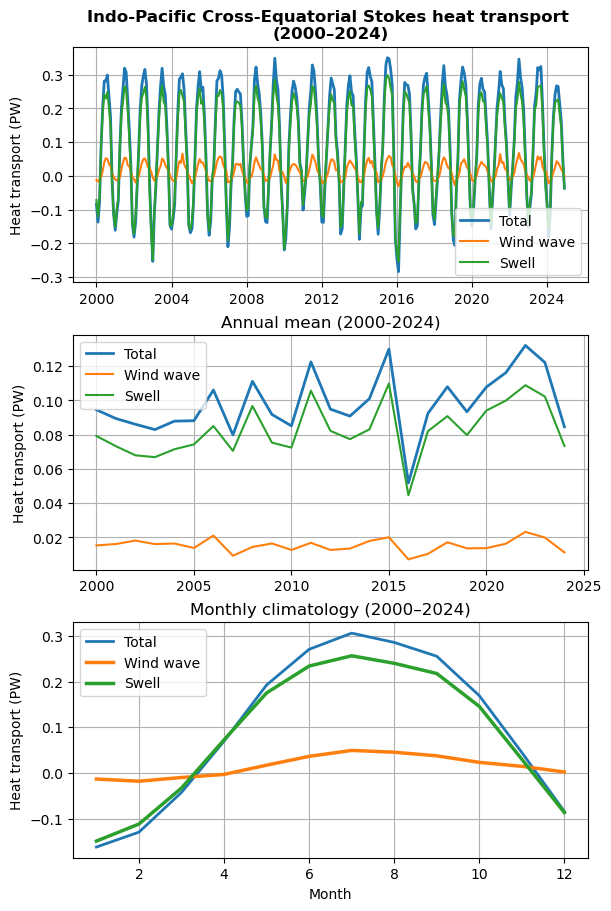

In [39]:
fig, axs = plt.subplots(3, 1, figsize=(6, 9), constrained_layout=True)

# -----------------------------
# (1) Full time series
# -----------------------------
axs[0].plot(ds_IP["Qtot"].time, ds_IP["Qtot"].values, label="Total", lw=2)
axs[0].plot(ds_IP["Qww"].time,  ds_IP["Qww"].values,  label="Wind wave", lw=1.5)
axs[0].plot(ds_IP["Qts"].time,  ds_IP["Qts"].values,  label="Swell", lw=1.5)
axs[0].set_title("Indo-Pacific Cross-Equatorial Stokes heat transport \n(2000–2024)", fontweight="bold")
axs[0].set_ylabel("Heat transport (PW)")
axs[0].grid(True)
axs[0].legend()

# the annual mean
axs[1].plot(ds_IP["Qtot_years"].year, ds_IP["Qtot_years"].values, label="Total", lw=2)
axs[1].plot(ds_IP["Qww_years"].year, ds_IP["Qww_years"].values, label="Wind wave", lw=1.5)
axs[1].plot(ds_IP["Qts_years"].year, ds_IP["Qts_years"].values, label="Swell", lw=1.5)
axs[1].set_title("Annual mean (2000-2024)")
axs[1].set_ylabel("Heat transport (PW)")
axs[1].grid(True)
axs[1].legend()

# -----------------------------
# (2) Monthly climatology
# -----------------------------
axs[2].plot(ds_IP["Qtot_months"].month, ds_IP["Qtot_months"].values, label="Total", lw=2)
axs[2].plot(ds_IP["Qww_months"].month, ds_IP["Qww_months"].values, label="Wind wave", lw=2.5)
axs[2].plot(ds_IP["Qts_months"].month, ds_IP["Qts_months"].values, label="Swell", lw=2.5)

axs[2].set_title("Monthly climatology (2000–2024)")
axs[2].set_xlabel("Month")
axs[2].set_ylabel("Heat transport (PW)")
axs[2].grid(True)
axs[2].legend()

plt.show()


In [86]:
def plot_heat_transport_column(axs_col, ds, region_name):
    """
    Plot one column (3 panels) of heat transport diagnostics.
    axs_col : list of 3 axes (top→bottom)
    ds      : dataset (ds_IP or ds_P)
    """

    colors = {
        "Total": "C0",
        "Wind wave": "C1",
        "Swell": "C2"
    }

    # ==================================================
    # (1) Full time series
    # ==================================================
    axs_col[0].plot(ds["Qtot"].time, ds["Qtot"],
                    label="Total", lw=2, color=colors["Total"])
    axs_col[0].plot(ds["Qww"].time, ds["Qww"],
                    label="Wind wave", lw=1.5, color=colors["Wind wave"])
    axs_col[0].plot(ds["Qts"].time, ds["Qts"],
                    label="Swell", lw=1.5, color=colors["Swell"])

    axs_col[0].set_title(
        f"{region_name} \nCross-Equatorial Stokes heat transport (2000–2024)",
        fontweight="bold"
    )
    axs_col[0].set_ylabel("PW")
    axs_col[0].grid(True)
    axs_col[0].legend()

    # ==================================================
    # (2) Annual means + climatological mean lines
    # ==================================================
    axs_col[1].plot(ds["Qtot_years"].year, ds["Qtot_years"],
                    lw=2, color=colors["Total"], label="Total")
    axs_col[1].plot(ds["Qww_years"].year, ds["Qww_years"],
                    lw=1.5, color=colors["Wind wave"], label="Wind wave")
    axs_col[1].plot(ds["Qts_years"].year, ds["Qts_years"],
                    lw=1.5, color=colors["Swell"], label="Swell")

    # --- climatological annual means ---
    mean_total = ds["Qtot_years"].mean()
    mean_ww    = ds["Qww_years"].mean()
    mean_ts    = ds["Qts_years"].mean()

    axs_col[1].axhline(mean_total, ls="--", color=colors["Total"], alpha=0.8)
    axs_col[1].axhline(mean_ww,    ls="--", color=colors["Wind wave"], alpha=0.8)
    axs_col[1].axhline(mean_ts,    ls="--", color=colors["Swell"], alpha=0.8)

    axs_col[1].set_title("Annual mean (2000–2024)")
    axs_col[1].set_ylabel("PW")
    axs_col[1].grid(True)
    axs_col[1].legend()

    # ==================================================
    # (3) Monthly climatology
    # ==================================================
    axs_col[2].plot(ds["Qtot_months"].month, ds["Qtot_months"],
                    lw=2, color=colors["Total"], label="Total")
    axs_col[2].plot(ds["Qww_months"].month, ds["Qww_months"],
                    lw=2.5, color=colors["Wind wave"], label="Wind wave")
    axs_col[2].plot(ds["Qts_months"].month, ds["Qts_months"],
                    lw=2.5, color=colors["Swell"], label="Swell")

    axs_col[2].set_title("Monthly climatology (2000–2024)")
    axs_col[2].set_xlabel("Month")
    axs_col[2].set_ylabel("PW")
    axs_col[2].grid(True)
    axs_col[2].legend()

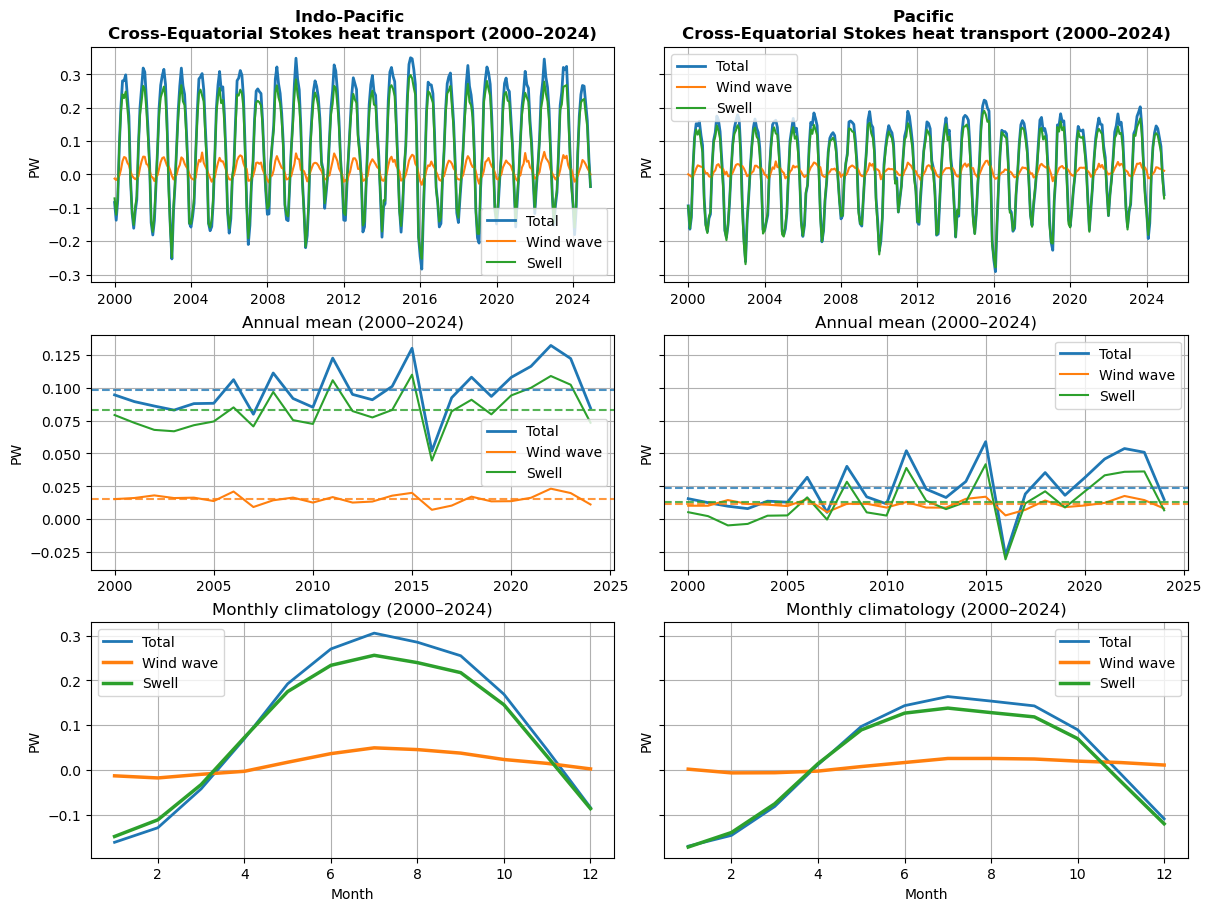

In [87]:
fig, axs = plt.subplots(
    3, 2,
    figsize=(12, 9),
    constrained_layout=True,
    sharey="row"
)

# Left column → Indo-Pacific
plot_heat_transport_column(axs[:, 0], ds_IP, "Indo-Pacific")

# Right column → Pacific
plot_heat_transport_column(axs[:, 1], ds_P, "Pacific")

plt.show()

## Zonally integrated Meridional OHT by Stokes drift for diff basins

In [73]:
# select region: Indo-Pacific
lon = wave_globe.longitude
lat = wave_globe.latitude

mask_IP = (
    (lat <= 60) & (lat >= -60) &                         # latitude band
    (lon >= 35) & (lon <= 290) &                         # Indo-Pacific sector
    ~((lon >= 263) & (lon <= 290) & (lat >= 20)) &       # remove Atlantic near North America
    ~((lat >= 10) & (lon >= 270) & (lon <= 290))
)

wave_IP = wave_globe.where(mask_IP)
sst_IP  = sst_time.where(mask_IP)

In [95]:
def get_basin_mask(lat, lon, basin_name="Indo-Pacific"):
    """
    Return a rough mask (True for points inside the basin) for the given basin.

    lat: xarray.DataArray of latitude
    lon: xarray.DataArray of longitude
    basin_name: str, one of ["Indo-Pacific", "Atlantic", "Indian", "Pacific"]
    """
    # Latitude band
    lat_mask = (lat >= -60) & (lat <= 60)

    # Longitude masks
    if basin_name == "Indo-Pacific":
        # Rough: 35E → 290E
        lon_mask = (lon >= 35) & (lon <= 290)
        # Remove small Atlantic wedges
        lon_mask = lon_mask & ~((lon >= 263) & (lon <= 290) & (lat >= 20))
        lon_mask = lon_mask & ~((lat >= 10) & (lon >= 270) & (lon <= 290))

    elif basin_name == "Atlantic":
        # Basically the complement of Indo-Pacific with Atlantic corrections
        lon_mask = ~((lon >= 35) & (lon <= 290))
        # Add wedges corresponding to North Atlantic region
        lon_mask = lon_mask | (((lon >= 263) & (lon <= 290) & (lat >= 20)))
        lon_mask = lon_mask | (((lat >= 10) & (lon >= 270) & (lon <= 290)))

    elif basin_name == "Indian":
        lon_mask = (lon >= 35) & (lon <= 120)

    elif basin_name == "Pacific":
        lon_mask = (lon >= 120) & (lon <= 290)

    else:
        raise ValueError(f"Unknown basin_name: {basin_name}")

    # Broadcast lat & lon to 2D mask
    mask_2d = lat_mask & lon_mask
    return mask_2d

mask_AT = get_basin_mask(lat, lon, basin_name="Atlantic")
mask_ID = get_basin_mask(lat, lon, basin_name="Indian")
mask_PA = get_basin_mask(lat, lon, basin_name="Pacific")

Text(0.5, 1.0, 'Indo-Pacific')

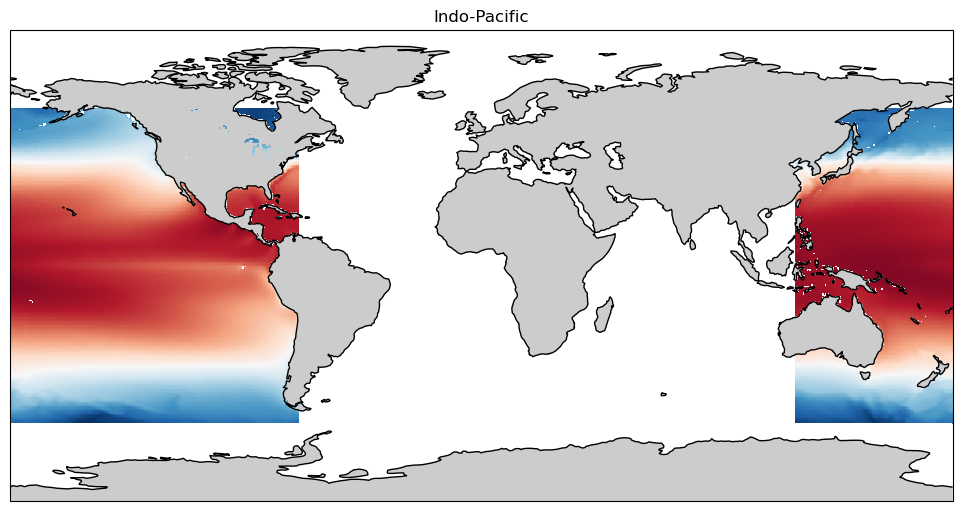

In [ ]:
sst_masked = sst_time.where(mask_PA)
mean_ht = sst_masked.mean(dim="time")
fig, ax = plt.subplots(1,1, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)
pcm = ax.pcolormesh(
        mean_ht.longitude, mean_ht.latitude, mean_ht,
        # vmin=-1e-4, vmax=1e-4,
        shading='auto', cmap='RdBu_r'
)

# ax.set_title(title, fontsize=14)
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Indo-Pacific")

In [97]:
# Apply mask to data
wave_IP = wave_globe.where(mask_IP)
sst_IP  = sst_time.where(mask_IP)

wave_AT = wave_globe.where(mask_AT)
sst_AT  = sst_time.where(mask_AT)

wave_ID = wave_globe.where(mask_ID)
sst_ID  = sst_time.where(mask_ID)

wave_PA = wave_globe.where(mask_PA)
sst_PA  = sst_time.where(mask_PA)

In [98]:
mask_lat = (lat >= -60) & (lat <= 60)
wave_glo = wave_globe.where(mask_lat)
sst_glo = sst_time.where(mask_lat)

In [99]:
def compute_stokes_OHT_masked(wave_ds, sst_ds):
    """
    Compute zonally integrated meridional Stokes heat transport (PW)
    from **already masked** data arrays (NaN outside the basin).

    wave_ds: Dataset with wave fields ('shww','mpww','mdww','shts','mpts','mdts')
    sst_ds: SST DataArray (K)

    Returns:
    OHT_total, OHT_wind, OHT_swell: DataArrays vs latitude
    """
    # Estimate Stokes transport
    V_u_ww, V_v_ww = estimate_stokes_transport(
        wave_ds["shww"], wave_ds["mpww"], wave_ds["mdww"]
    )
    V_u_ts, V_v_ts = estimate_stokes_transport(
        wave_ds["shts"], wave_ds["mpts"], wave_ds["mdts"]
    )
    V_v_total = V_v_ww + V_v_ts

    # Heat transport per unit longitude (J m^-1 s^-1)
    rho_w = 1025
    cp = 3985
    HT_total = rho_w * cp * V_v_total * (sst_ds - 273.15)
    HT_ww = rho_w * cp * V_v_ww * (sst_ds - 273.15)
    HT_ts = rho_w * cp * V_v_ts * (sst_ds - 273.15)

    # Zonally integrate
    R = 6371000  # Earth radius
    lon_rad = np.deg2rad(sst_ds.longitude)
    dlon = np.gradient(lon_rad)
    lat_rad = np.deg2rad(sst_ds.latitude)

    dx = xr.DataArray(
        R * np.cos(lat_rad).values[:, None] * dlon[None, :],
        coords={"latitude": sst_ds.latitude, "longitude": sst_ds.longitude},
        dims=["latitude", "longitude"]
    )

    OHT_total = (HT_total * dx).sum(dim="longitude") / 1e15
    OHT_ww = (HT_ww * dx).sum(dim="longitude") / 1e15
    OHT_ts = (HT_ts * dx).sum(dim="longitude") / 1e15

    return OHT_total, OHT_ww, OHT_ts

In [100]:
OHT_total_IP, OHT_ww_IP, OHT_ts_IP = compute_stokes_OHT_masked(wave_IP, sst_IP)
OHT_total_AT, OHT_ww_AT, OHT_ts_AT = compute_stokes_OHT_masked(wave_AT, sst_AT)
OHT_total_ID, OHT_ww_ID, OHT_ts_ID = compute_stokes_OHT_masked(wave_ID, sst_ID)
OHT_total_PA, OHT_ww_PA, OHT_ts_PA = compute_stokes_OHT_masked(wave_PA, sst_PA)
OHT_total_glo, OHT_ww_glo, OHT_ts_glo = compute_stokes_OHT_masked(wave_glo, sst_glo)

In [101]:
OHT_total_IP = OHT_total_IP.mean(dim="time")
OHT_ww_IP    = OHT_ww_IP.mean(dim="time")
OHT_ts_IP    = OHT_ts_IP.mean(dim="time")

OHT_total_AT = OHT_total_AT.mean(dim="time")
OHT_ww_AT    = OHT_ww_AT.mean(dim="time")
OHT_ts_AT    = OHT_ts_AT.mean(dim="time")

OHT_total_ID = OHT_total_ID.mean(dim="time")
OHT_ww_ID    = OHT_ww_ID.mean(dim="time")
OHT_ts_ID    = OHT_ts_ID.mean(dim="time")

OHT_total_PA = OHT_total_PA.mean(dim="time")
OHT_ww_PA    = OHT_ww_PA.mean(dim="time")
OHT_ts_PA    = OHT_ts_PA.mean(dim="time")

OHT_total_glo = OHT_total_glo.mean(dim="time")
OHT_ww_glo    = OHT_ww_glo.mean(dim="time")
OHT_ts_glo    = OHT_ts_glo.mean(dim="time")

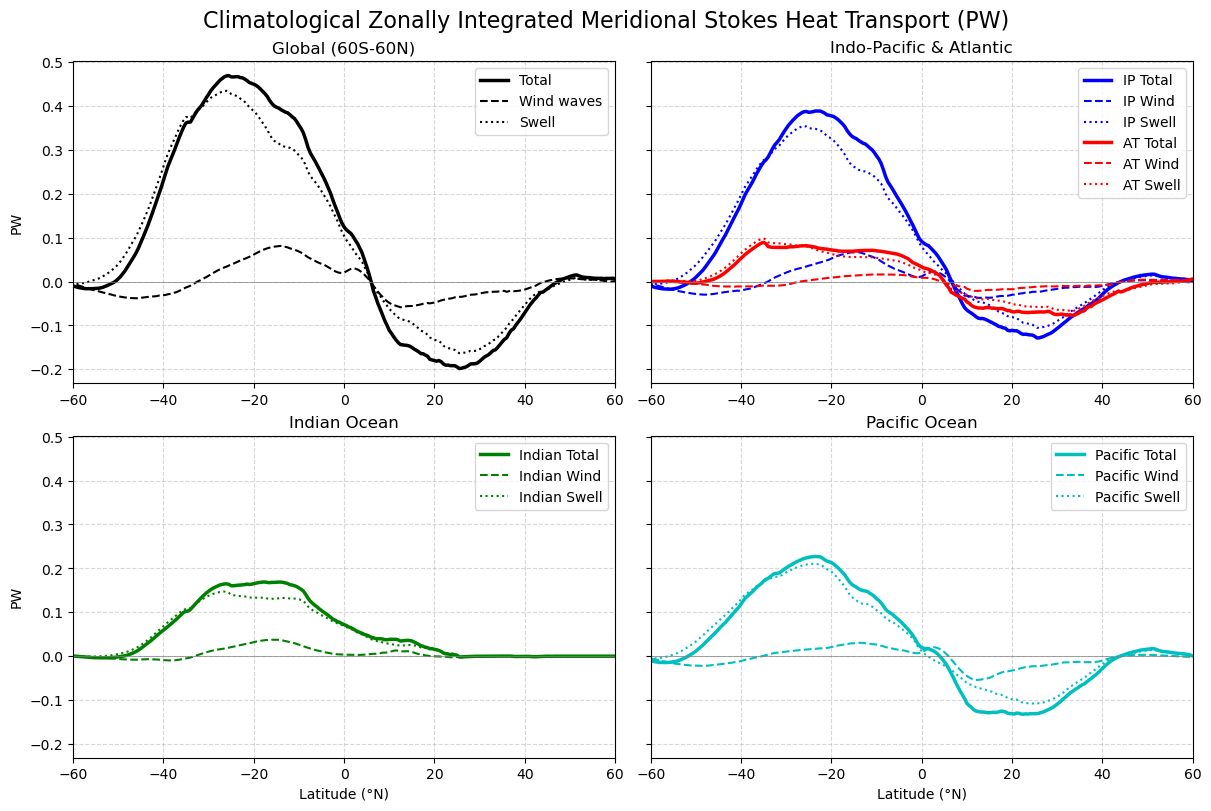

In [114]:
fig, axs = plt.subplots(2, 2, figsize=(12,8), constrained_layout=True, sharey=True)

# -------------------------
# Top-left: Global
# -------------------------
axs[0,0].plot(sst_glo.latitude, OHT_total_glo, color="k", lw=2.5, label="Total")
axs[0,0].plot(sst_glo.latitude, OHT_ww_glo, color="k", lw=1.5, ls="--", label="Wind waves")
axs[0,0].plot(sst_glo.latitude, OHT_ts_glo, color="k", lw=1.5, ls=":", label="Swell")
axs[0,0].set_xlim(-60,60)
axs[0,0].axhline(0, color='gray', lw=0.5)
axs[0,0].set_title("Global (60S-60N)")
axs[0,0].set_ylabel("PW")
axs[0,0].legend()
axs[0,0].grid(True, linestyle='--', alpha=0.5)

# -------------------------
# Top-right: Indo-Pacific & Atlantic
# -------------------------
# Indo-Pacific
axs[0,1].plot(sst_IP.latitude, OHT_total_IP, color="b", lw=2.5, label="IP Total")
axs[0,1].plot(sst_IP.latitude, OHT_ww_IP, color="b", lw=1.5, ls="--", label="IP Wind")
axs[0,1].plot(sst_IP.latitude, OHT_ts_IP, color="b", lw=1.5, ls=":", label="IP Swell")
axs[0,1].set_xlim(-60,60)
# Atlantic
axs[0,1].plot(sst_AT.latitude, OHT_total_AT, color="r", lw=2.5, label="AT Total")
axs[0,1].plot(sst_AT.latitude, OHT_ww_AT, color="r", lw=1.5, ls="--", label="AT Wind")
axs[0,1].plot(sst_AT.latitude, OHT_ts_AT, color="r", lw=1.5, ls=":", label="AT Swell")
axs[0,1].axhline(0, color='gray', lw=0.5)
axs[0,1].set_title("Indo-Pacific & Atlantic")
axs[0,1].legend()
axs[0,1].grid(True, linestyle='--', alpha=0.5)

# -------------------------
# Bottom-left: Indian Ocean
# -------------------------
axs[1,0].plot(sst_ID.latitude, OHT_total_ID, color="g", lw=2.5, label="Indian Total")
axs[1,0].plot(sst_ID.latitude, OHT_ww_ID, color="g", lw=1.5, ls="--", label="Indian Wind")
axs[1,0].plot(sst_ID.latitude, OHT_ts_ID, color="g", lw=1.5, ls=":", label="Indian Swell")
axs[1,0].set_xlim(-60,60)
axs[1,0].axhline(0, color='gray', lw=0.5)
axs[1,0].set_title("Indian Ocean")
axs[1,0].set_xlabel("Latitude (°N)")
axs[1,0].set_ylabel("PW")
axs[1,0].legend()
axs[1,0].grid(True, linestyle='--', alpha=0.5)

# -------------------------
# Bottom-right: Pacific Ocean
# -------------------------
axs[1,1].plot(sst_PA.latitude, OHT_total_PA, color="c", lw=2.5, label="Pacific Total")
axs[1,1].plot(sst_PA.latitude, OHT_ww_PA, color="c", lw=1.5, ls="--", label="Pacific Wind")
axs[1,1].plot(sst_PA.latitude, OHT_ts_PA, color="c", lw=1.5, ls=":", label="Pacific Swell")
axs[1,1].set_xlim(-60,60)
axs[1,1].axhline(0, color='gray', lw=0.5)
axs[1,1].set_title("Pacific Ocean")
axs[1,1].set_xlabel("Latitude (°N)")
axs[1,1].legend()
axs[1,1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Climatological Zonally Integrated Meridional Stokes Heat Transport (PW)", fontsize=16)
plt.show()

In [75]:
# Estimate Stokes transport
# Indo-Pacific
# wind wave and total swell
Vst_u_ww_IP, Vst_v_ww_IP = estimate_stokes_transport(wave_IP["shww"], wave_IP["mpww"], wave_IP["mdww"])
Vst_u_ts_IP, Vst_v_ts_IP = estimate_stokes_transport(wave_IP["shts"], wave_IP["mpts"], wave_IP["mdts"])
# total
Vst_u_IP = Vst_u_ww_IP + Vst_u_ts_IP
Vst_v_IP = Vst_v_ww_IP + Vst_v_ts_IP

In [76]:
# Focus only on the meridional transport (V-component)
rho_w = 1025 # kg m-3
cp = 3985    # J kg-1 K-1

# Indo-Pacific
HT_IP = rho_w * cp * Vst_v_IP * (sst_IP - 273.15)       # unit: (kg m-3) * (J kg-1 K-1) * (m2 s-1) * (K) = J m-1 s-1
HT_ww_IP = rho_w * cp * Vst_v_ww_IP * (sst_IP - 273.15)
HT_ts_IP = rho_w * cp * Vst_v_ts_IP * (sst_IP - 273.15)

In [ ]:
# Zonnaly integrated heat transport in the Indo-Pacific basin
R = 6371000  # Earth radius (m)

# Convert longitude to radians
lon_rad = np.deg2rad(sst_IP.longitude)
dlon = np.gradient(lon_rad)  # in radians

# Convert latitude to radians
lat_rad = np.deg2rad(sst_IP.latitude)

# Create dx as a DataArray, automatically broadcast along latitude and longitude
dx = xr.DataArray(
    R * np.cos(lat_rad).values[:, None] * dlon[None, :],  # shape: (lat, lon)
    coords={"latitude": sst_IP.latitude, "longitude": sst_IP.longitude},
    dims=["latitude", "longitude"]
)

# HT_IP: J m-1 s-1, dx: m
# zonal sum → J/s = W
OHT_IP = (HT_IP * dx).sum(dim="longitude") / 1e15
OHT_ww_IP = (HT_ww_IP * dx).sum(dim="longitude") / 1e15
OHT_ts_IP = (HT_ts_IP * dx).sum(dim="longitude") / 1e15


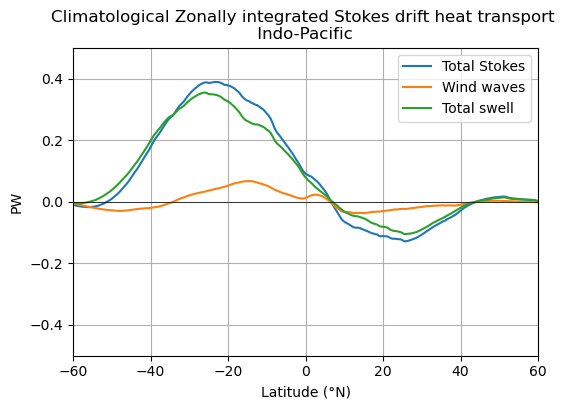

In [88]:

plt.figure(figsize=(6,4))
plt.plot(sst_IP.latitude, OHT_IP.mean(dim='time'), label="Total Stokes")
plt.plot(sst_IP.latitude, OHT_ww_IP.mean(dim='time'), label="Wind waves")
plt.plot(sst_IP.latitude, OHT_ts_IP.mean(dim='time'), label="Total swell")
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("Latitude (°N)")
plt.xlim(-60, 60)
plt.ylim(-0.5, 0.5)
plt.ylabel("PW")
plt.title("Climatological Zonally integrated Stokes drift heat transport \n Indo-Pacific ")
plt.legend()
plt.grid(True)
plt.show()